## About Dataset

Lending Club

Lending Club is a peer-to-peer Lending company based in the US. They match people looking to invest money with people looking to borrow money. When investors invest their money through Lending Club, this money is passed onto borrowers, and when borrowers pay their loans back, the capital plus the interest passes on back to the investors. It is a win for everybody as they can get typically lower loan rates and higher investor returns.

The Lending Club dataset contains complete loan data for all loans issued through the 2007-2015, including the current loan status (Current, Late, Fully Paid, etc.) and latest payment information. Features (aka variables) include credit scores, number of finance inquiries, address including zip codes and state, and collections among others. Collections indicates whether the customer has missed one or more payments and the team is trying to recover their money. The file is a matrix of about 890 thousand observations and 75 variables.


Grade | Risk Level | Typical Interest Rate
---|---:|---:
A | Lowest risk | ~6–8%
B | Low risk | ~9–12%
C | Moderate risk | ~13–16%
D | Medium-high risk | ~17–20%
E | High risk | ~21–24%
F | Very high risk | ~25–28%
G | Highest risk | ~29%+

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
pd.options.display.max_rows = None

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adarshsng/lending-club-loan-data-csv")

print("Path to dataset files:", path)

100%|██████████| 339M/339M [00:05<00:00, 63.2MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/adarshsng/lending-club-loan-data-csv/versions/1


In [5]:
import os
print(os.listdir(path))

['loan.csv', 'LCDataDictionary.xlsx']


In [6]:
df = pd.read_csv(os.path.join(path, 'loan.csv'), nrows = 100000)
df.head()

/tmp/ipykernel_7235/2934115214.py:1: DtypeWarning: Columns (123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(path, 'loan.csv'), nrows = 100000)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## EDA

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,100000.0,15934.297500,10146.154617,1000.00,8000.00,14000.00,21500.0000,4.000000e+04
funded_amnt,100000.0,15934.297500,10146.154617,1000.00,8000.00,14000.00,21500.0000,4.000000e+04
funded_amnt_inv,100000.0,15931.464250,10148.296023,725.00,8000.00,14000.00,21500.0000,4.000000e+04
int_rate,100000.0,13.004960,5.026647,6.00,8.81,11.80,16.1400,3.099000e+01
installment,100000.0,462.493739,285.647728,30.64,252.97,380.81,622.6800,1.618240e+03
annual_inc,100000.0,83149.960273,111761.282696,0.00,47840.00,68613.00,100000.0000,9.757200e+06
url,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
desc,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Check missing values

In [8]:
df.isnull().sum().sort_values(ascending=False)

,0
id,100000
member_id,100000
url,100000
desc,100000
hardship_start_date,99999
hardship_loan_status,99999
orig_projected_additional_accrued_interest,99999
deferral_term,99999
hardship_status,99999
settlement_status,99999


In [9]:
drop_missing_columns = list(df.columns[df.isnull().sum() > 250000])
drop_missing_columns

[]

In [10]:
df.drop(columns = drop_missing_columns, inplace=True, axis = 1)

In [11]:
numerical = list(df.dtypes[df.dtypes != 'object'].index)
categorical = list(df.dtypes[df.dtypes == 'object'].index)
categorical

['term',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'earliest_cr_line',
 'initial_list_status',
 'last_pymnt_d',
 'next_pymnt_d',
 'last_credit_pull_d',
 'application_type',
 'verification_status_joint',
 'sec_app_earliest_cr_line',
 'hardship_flag',
 'hardship_type',
 'hardship_reason',
 'hardship_status',
 'hardship_start_date',
 'hardship_end_date',
 'payment_plan_start_date',
 'hardship_loan_status',
 'disbursement_method',
 'debt_settlement_flag',
 'debt_settlement_flag_date',
 'settlement_status',
 'settlement_date']

#### Check variable variance

In [12]:
df[numerical].apply(lambda x: x.std()).sort_values()

,0
collection_recovery_fee,0.000000
policy_code,0.000000
acc_now_delinq,0.000000
recoveries,0.000000
num_tl_30dpd,0.000000
tax_liens,0.000000
num_tl_120dpd_2m,0.000000
chargeoff_within_12_mths,0.094864
collections_12_mths_ex_med,0.148212
pub_rec_bankruptcies,0.333672


In [13]:
df['chargeoff_within_12_mths'].value_counts()

,count
chargeoff_within_12_mths,
0,99348
1,610
2,32
3,5
4,3
7,1
5,1


In [14]:
df['policy_code'].value_counts()

,count
policy_code,
1,100000


In [15]:
df['num_tl_120dpd_2m'].value_counts()

,count
num_tl_120dpd_2m,
0.0,97514


In [16]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)  # tune this

numeric_cols = df.select_dtypes(include='number').columns

selector.fit(df[numeric_cols])

# See which columns are kept
kept = numeric_cols[selector.get_support()]
dropped = numeric_cols[~selector.get_support()]
print("Dropped:", dropped.tolist())

Dropped: ['id', 'member_id', 'url', 'desc', 'recoveries', 'collection_recovery_fee', 'policy_code', 'acc_now_delinq', 'chargeoff_within_12_mths', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'tax_liens', 'deferral_term', 'hardship_amount', 'hardship_length', 'hardship_dpd', 'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 'settlement_amount', 'settlement_percentage', 'settlement_term']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_variance_threshold.py:114: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)


In [17]:
len(dropped)

22

In [18]:
dict = pd.read_excel(os.path.join(path, 'LCDataDictionary.xlsx'))
dict

,LoanStatNew,Description
0,acc_now_delinq,The number of accounts on which the borrower i...
1,acc_open_past_24mths,Number of trades opened in past 24 months.
2,addr_state,The state provided by the borrower in the loan...
3,all_util,Balance to credit limit on all trades
4,annual_inc,The self-reported annual income provided by th...
5,annual_inc_joint,The combined self-reported annual income provi...
6,application_type,Indicates whether the loan is an individual ap...
7,avg_cur_bal,Average current balance of all accounts
8,bc_open_to_buy,Total open to buy on revolving bankcards.
9,bc_util,Ratio of total current balance to high credit/...


In [19]:
for col in categorical:
    print(col, df[col].nunique())
    if df[col].nunique() < 10:
        print(df[col].value_counts())
    print()

term 2
term
36 months    68613
60 months    31387
Name: count, dtype: int64

grade 7
grade
A    28941
B    28091
C    24527
D    13335
E     4875
F      174
G       57
Name: count, dtype: int64

sub_grade 35

emp_title 35595

emp_length 11

home_ownership 4
home_ownership
MORTGAGE    49453
RENT        39320
OWN         10961
ANY           266
Name: count, dtype: int64

verification_status 3
verification_status
Not Verified       46431
Source Verified    38118
Verified           15451
Name: count, dtype: int64

issue_d 3
issue_d
Nov-2018    41970
Dec-2018    40134
Oct-2018    17896
Name: count, dtype: int64

loan_status 6
loan_status
Current               96793
Fully Paid             2431
Late (31-120 days)      318
In Grace Period         316
Late (16-30 days)       123
Charged Off              19
Name: count, dtype: int64

pymnt_plan 2
pymnt_plan
n    99999
y        1
Name: count, dtype: int64

purpose 12

title 12

zip_code 875

addr_state 50

earliest_cr_line 638

initial_list_statu

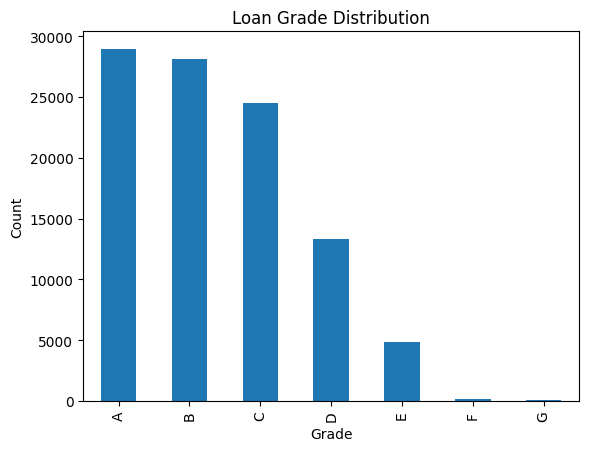

In [20]:
df['grade'].value_counts().sort_index().plot(kind='bar')
plt.title('Loan Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.show()

### Bivariate charts

/tmp/ipykernel_7235/866535275.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 4))


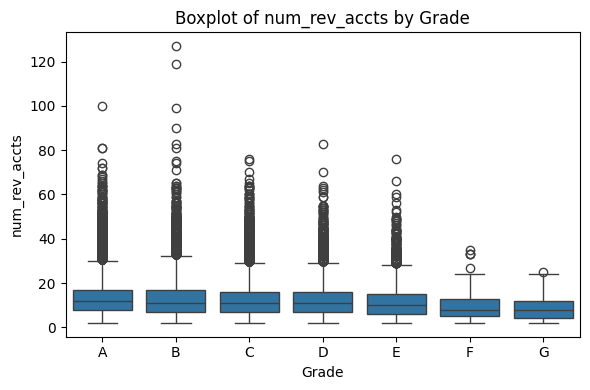

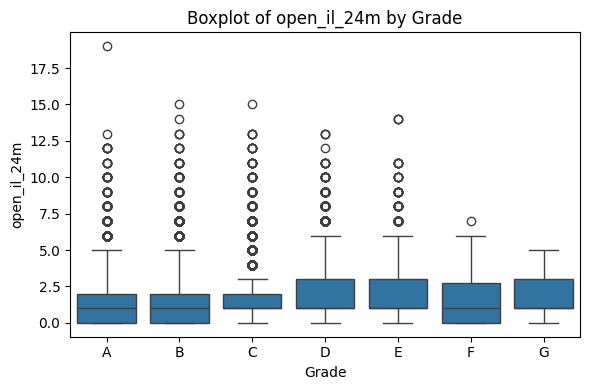

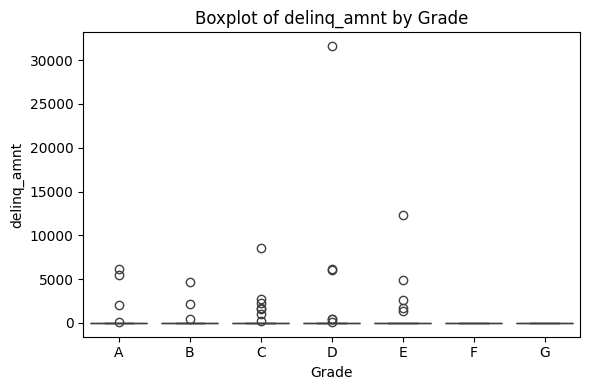

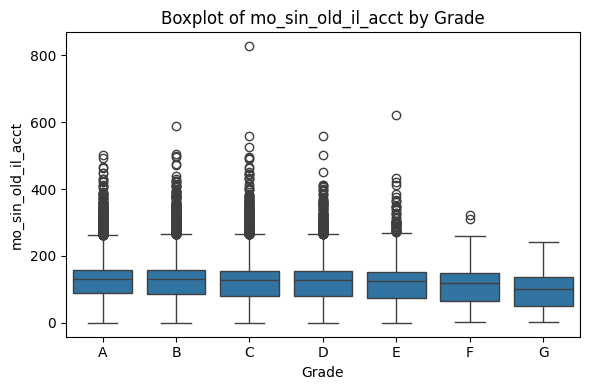

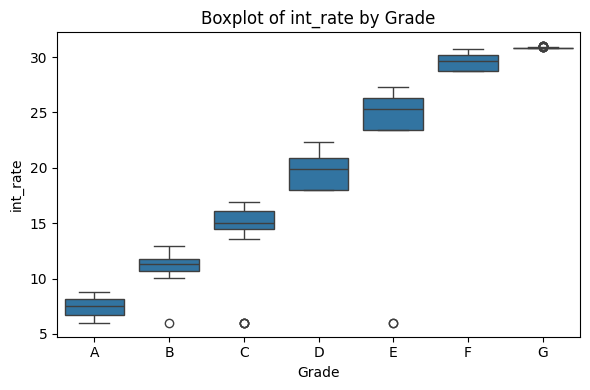

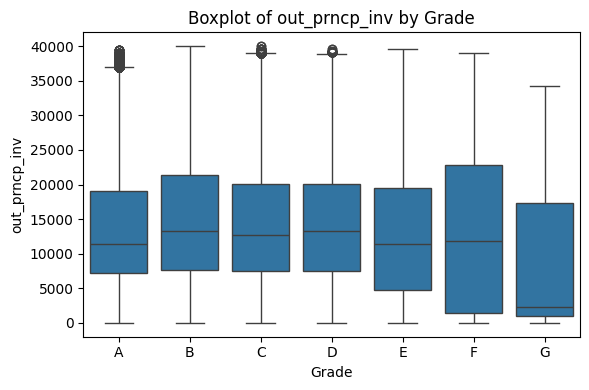

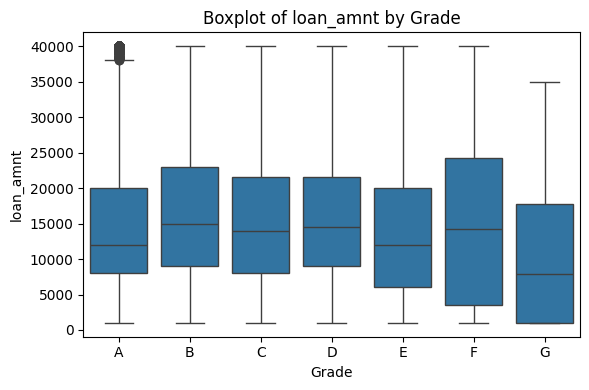

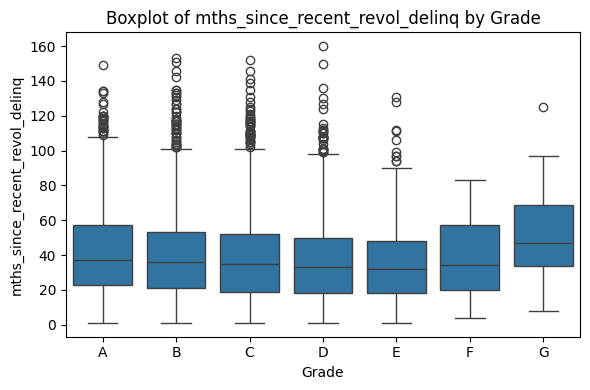

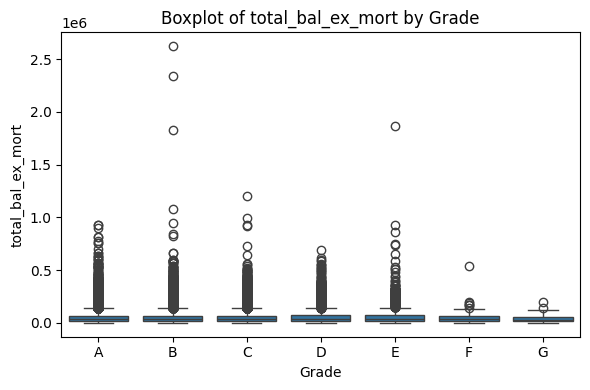

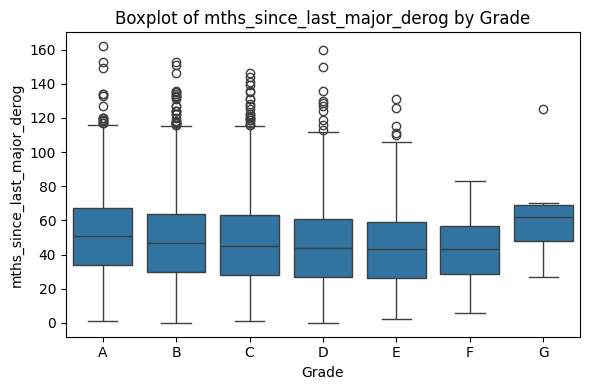

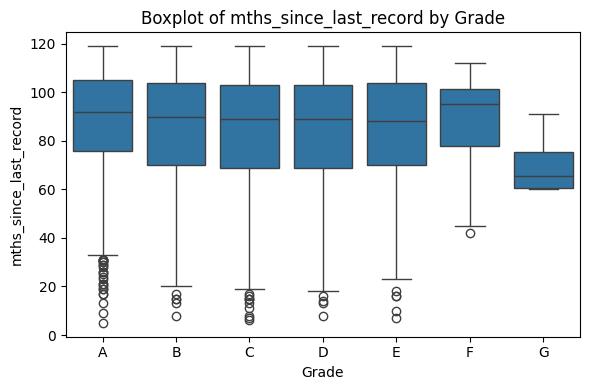

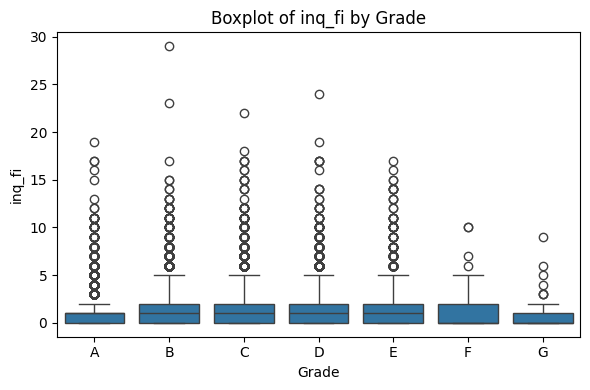

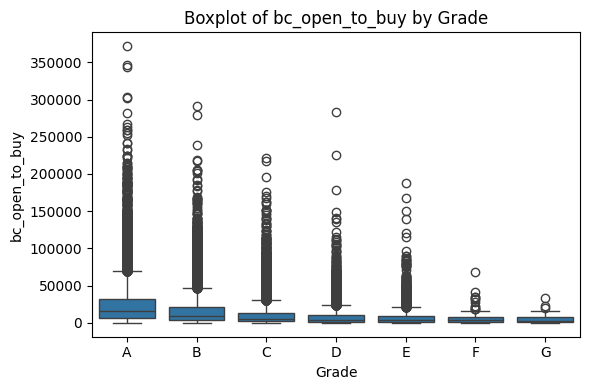

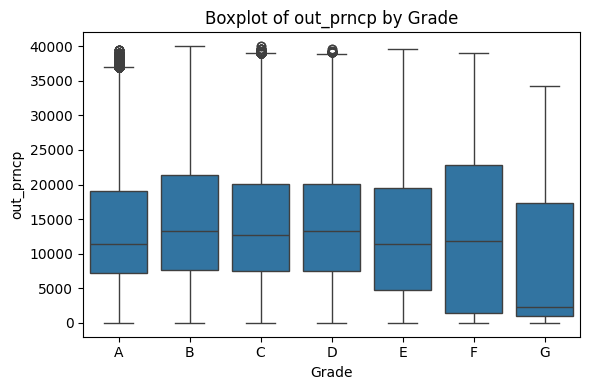

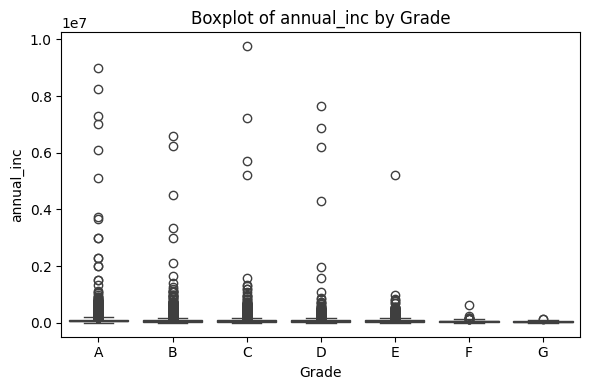

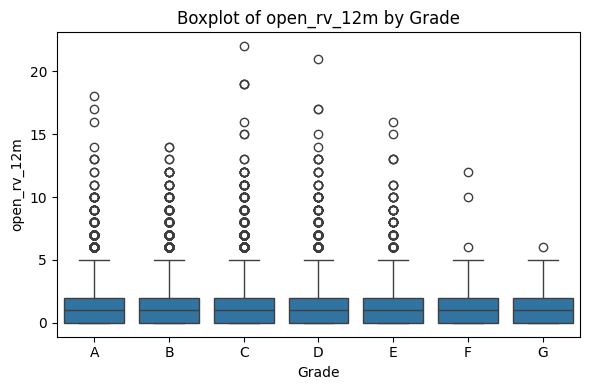

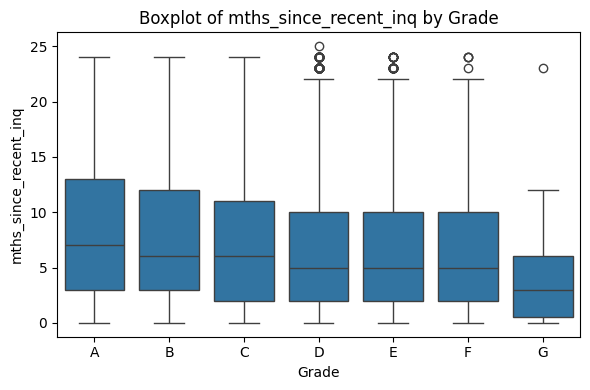

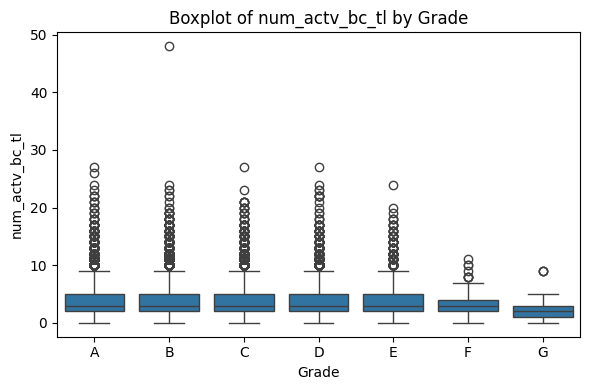

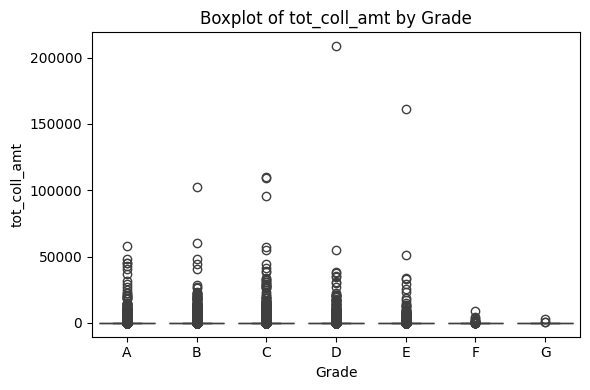

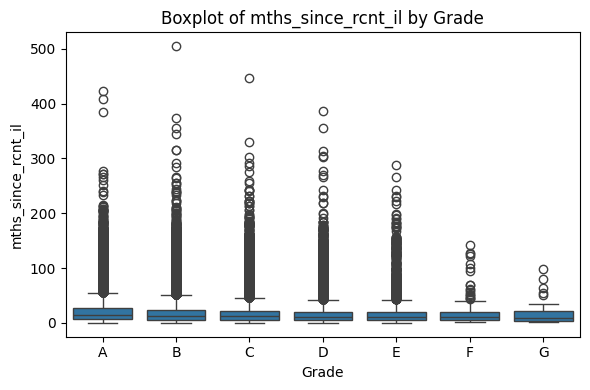

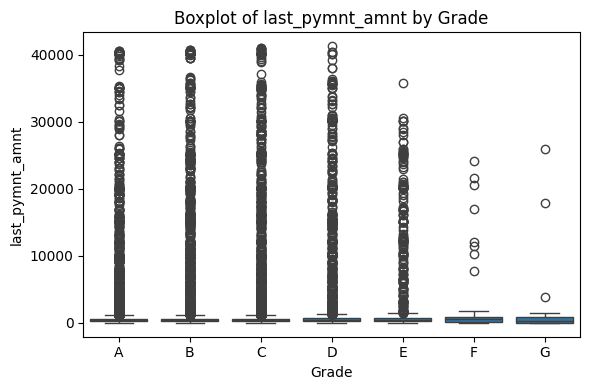

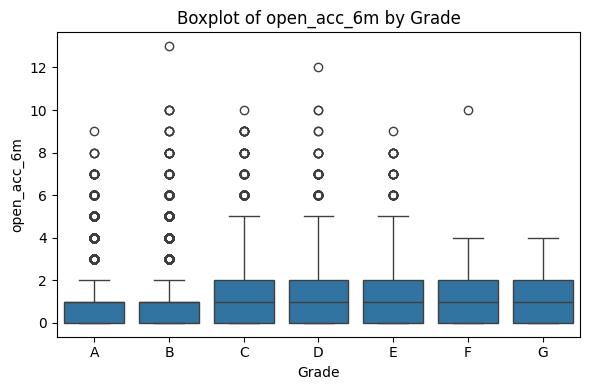

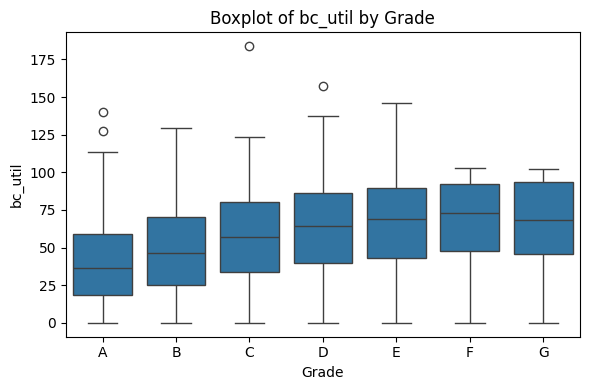

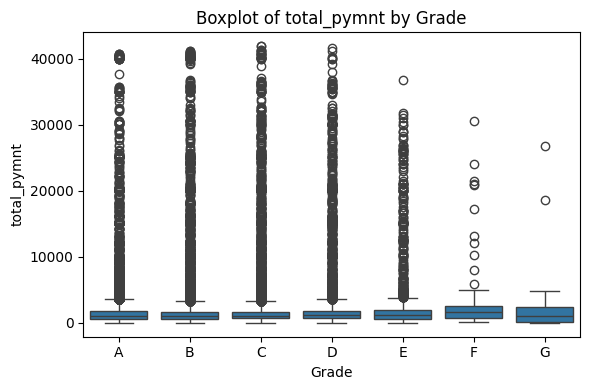

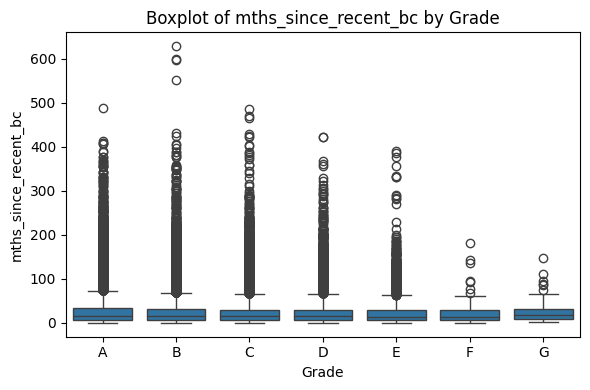

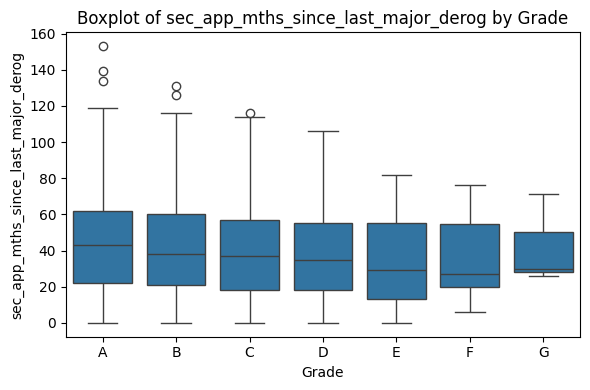

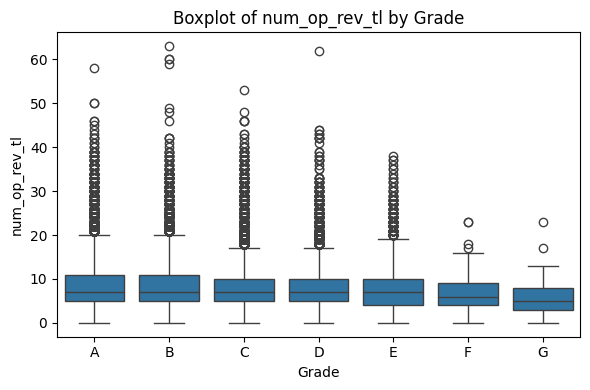

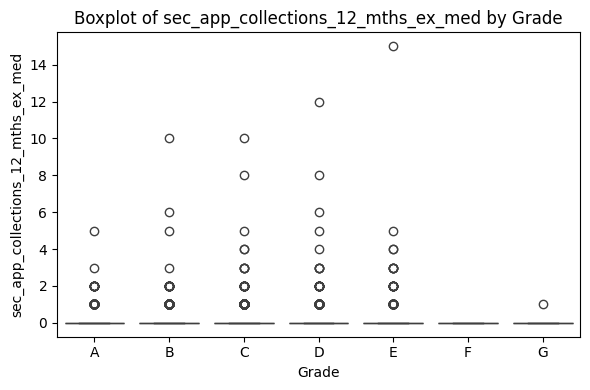

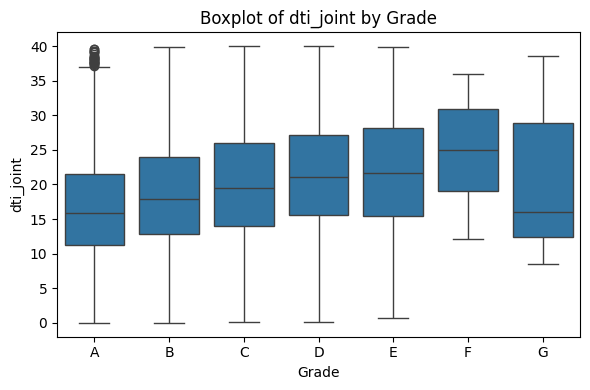

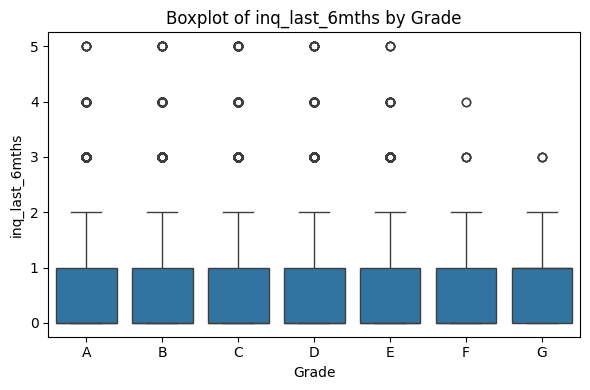

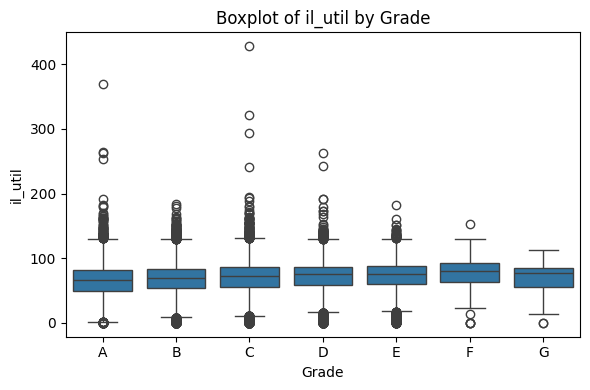

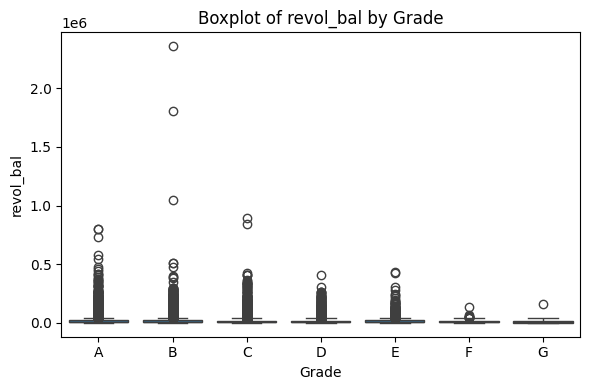

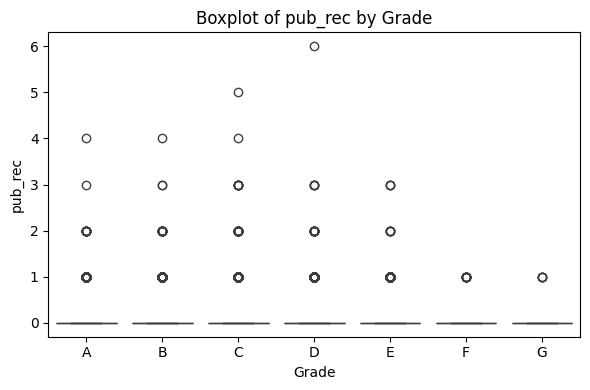

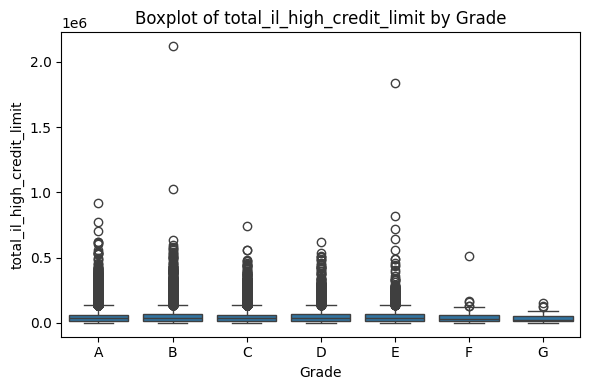

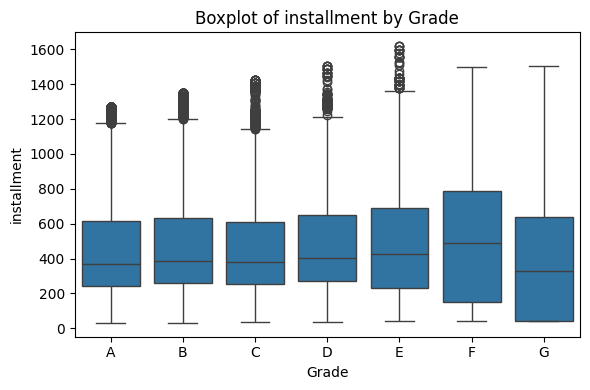

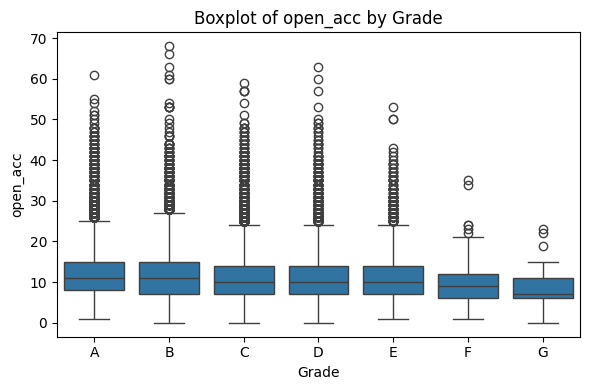

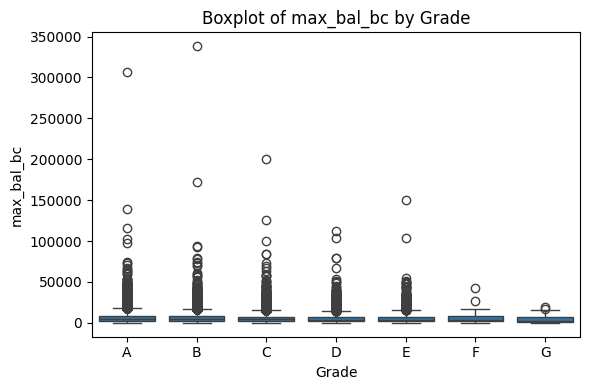

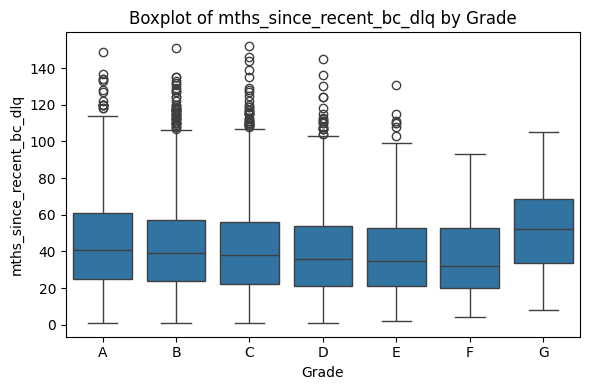

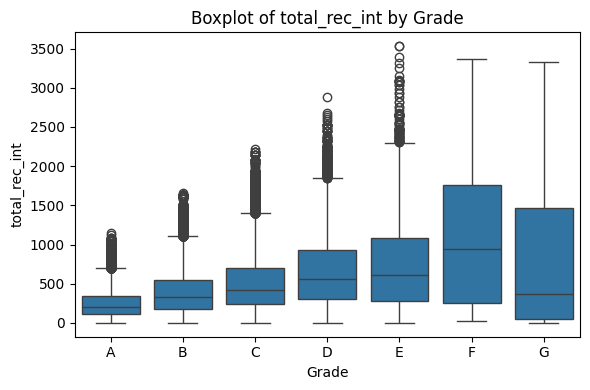

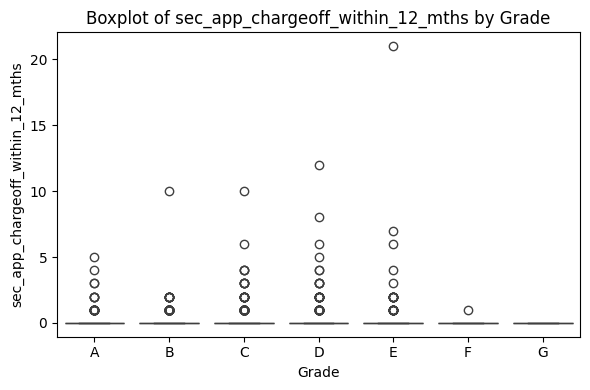

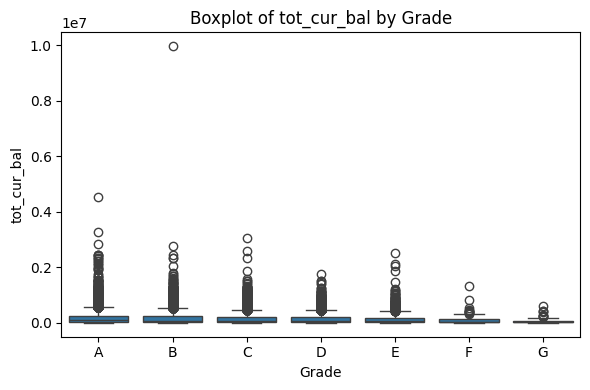

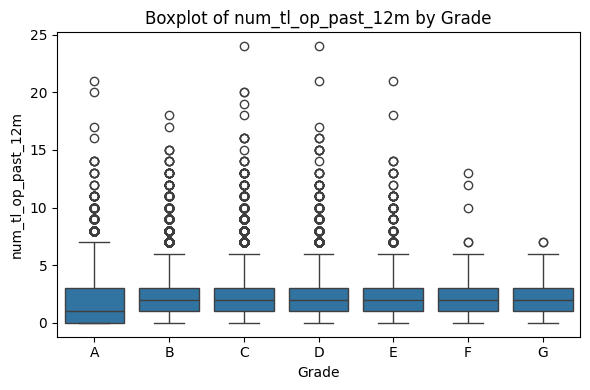

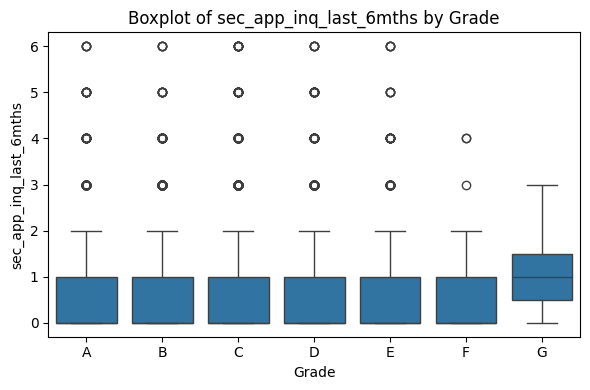

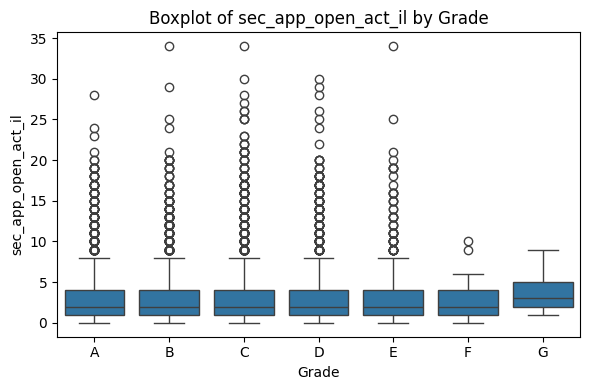

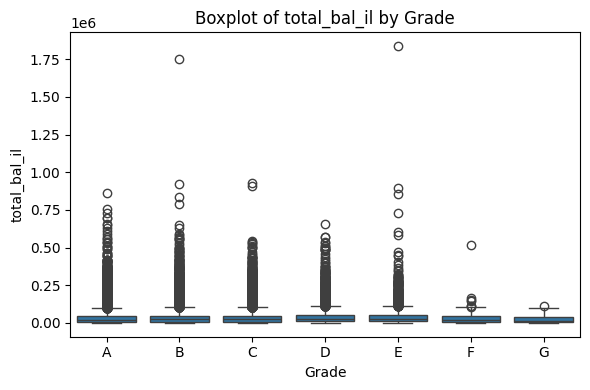

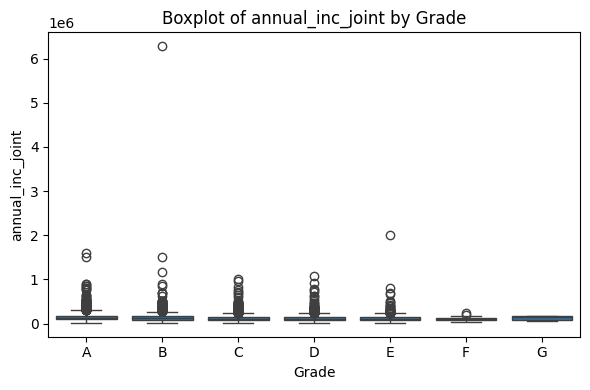

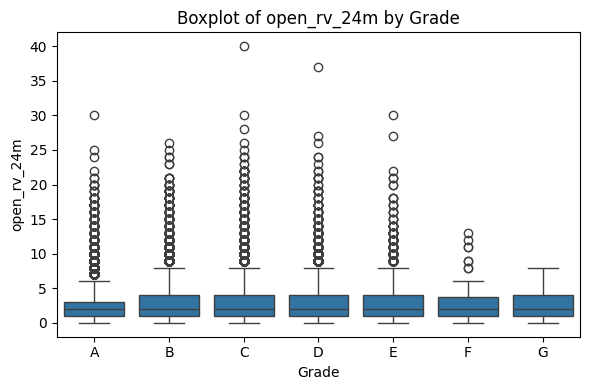

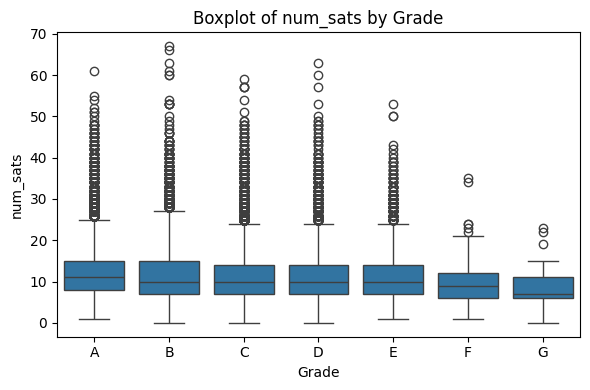

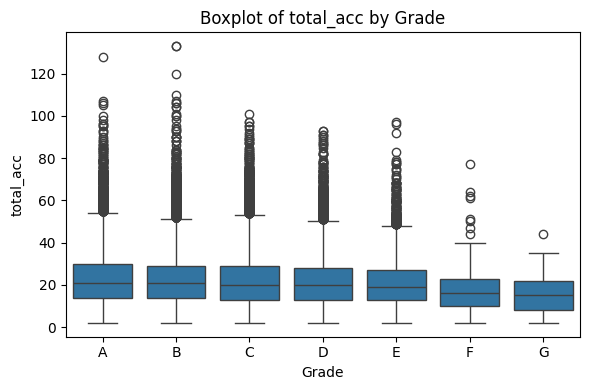

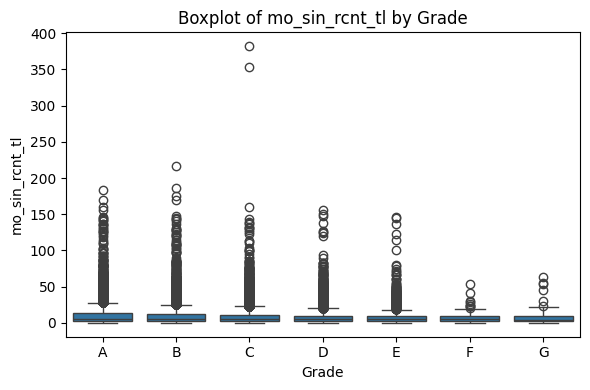

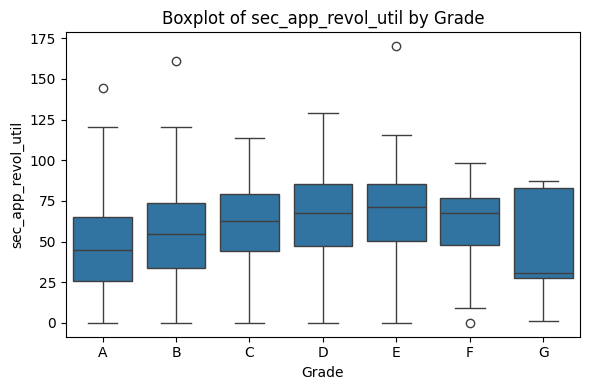

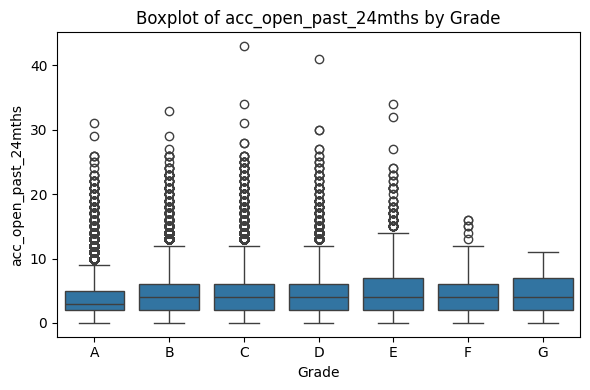

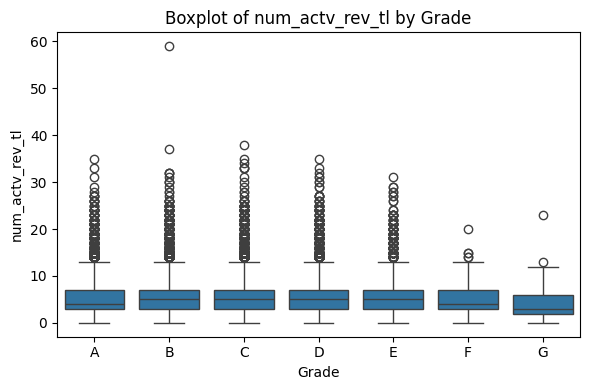

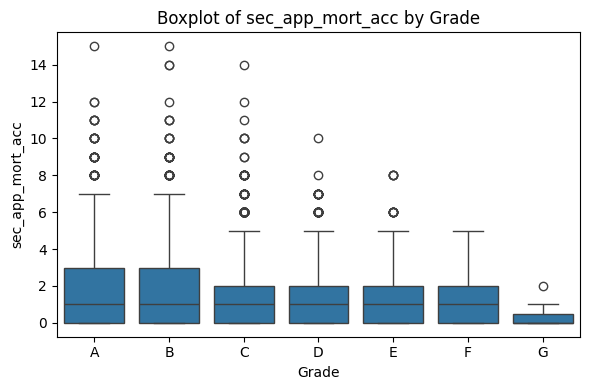

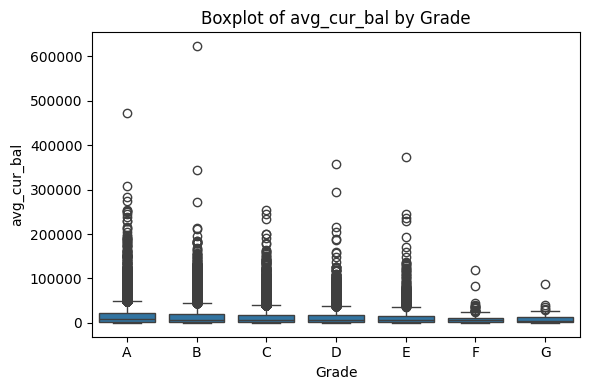

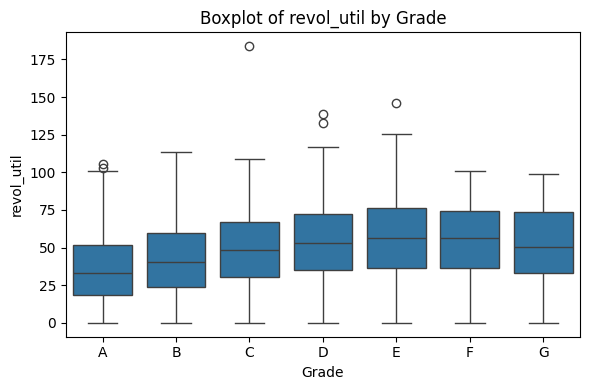

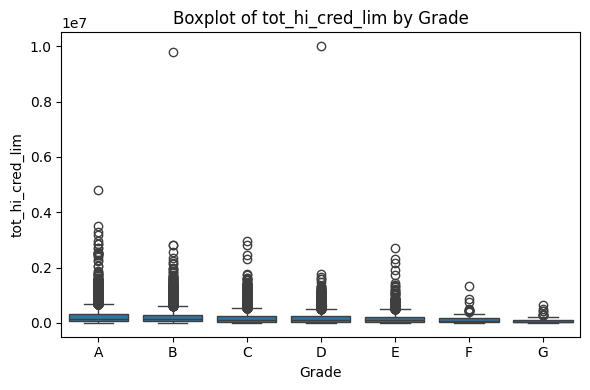

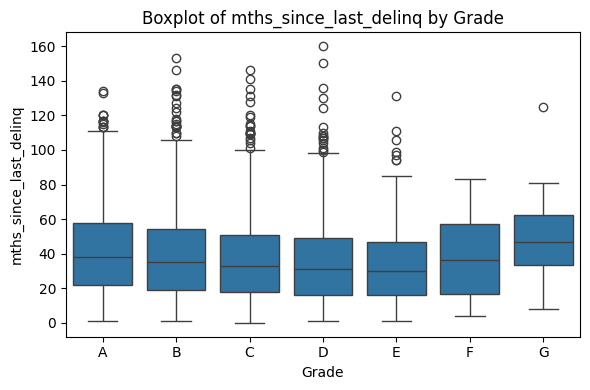

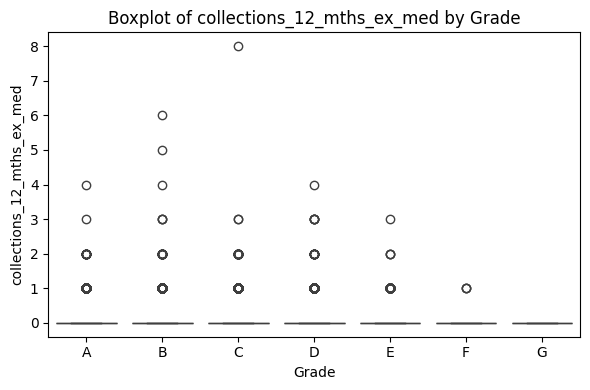

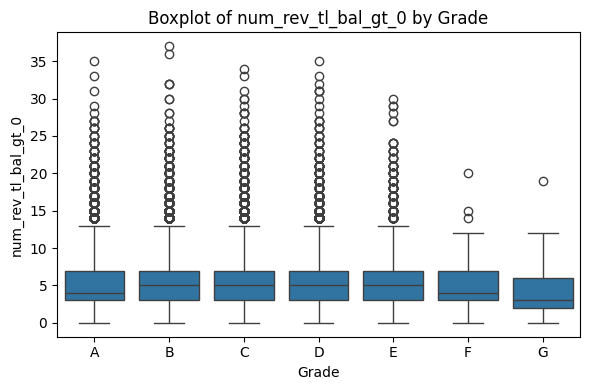

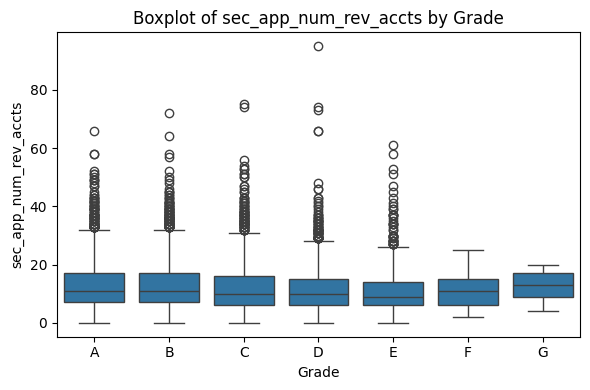

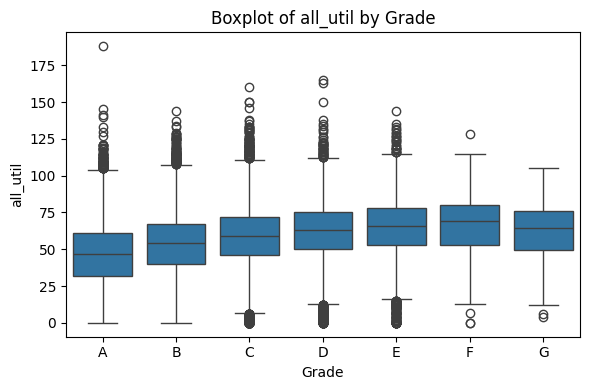

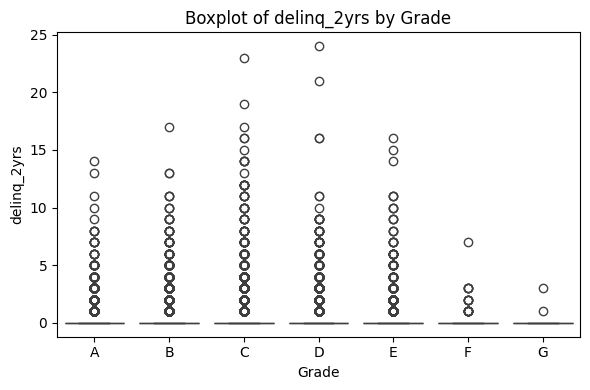

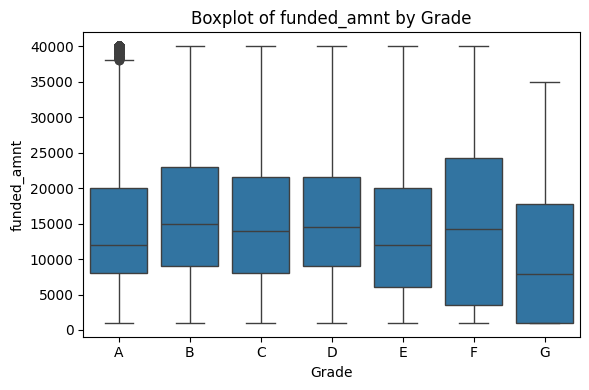

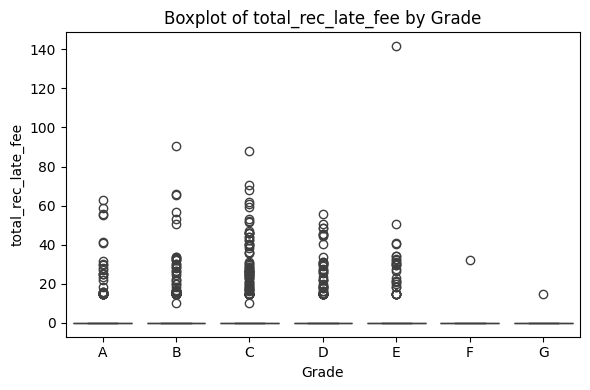

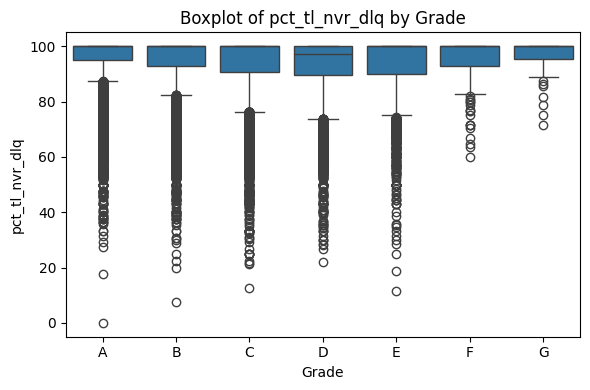

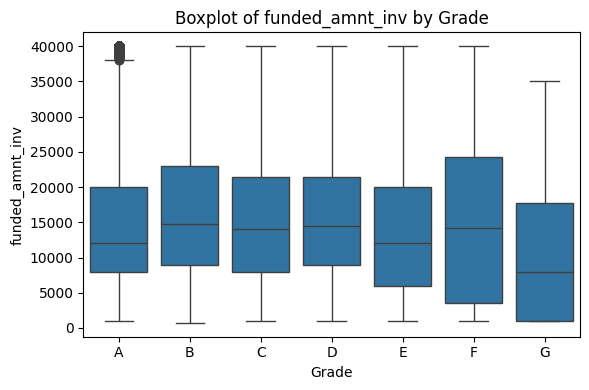

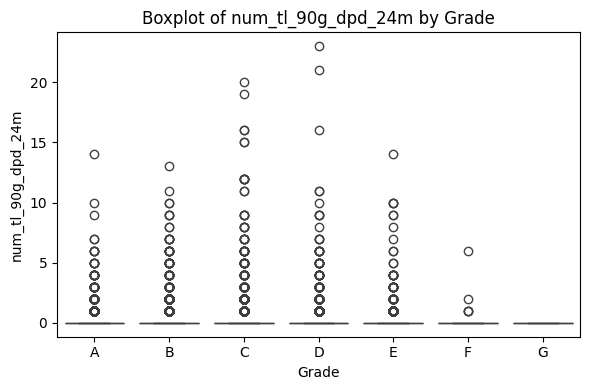

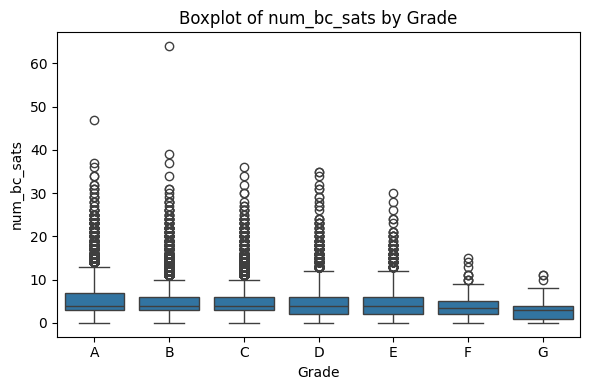

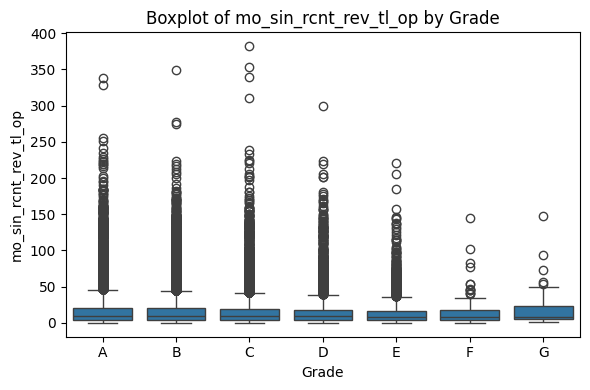

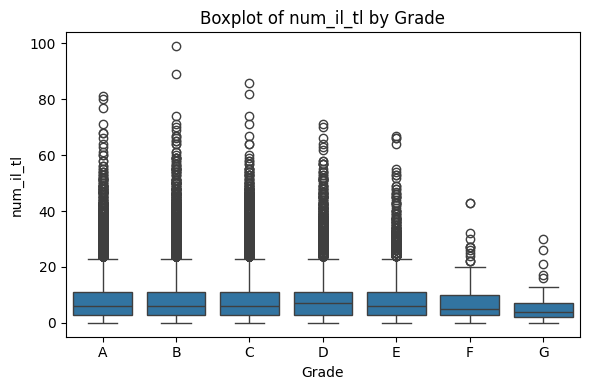

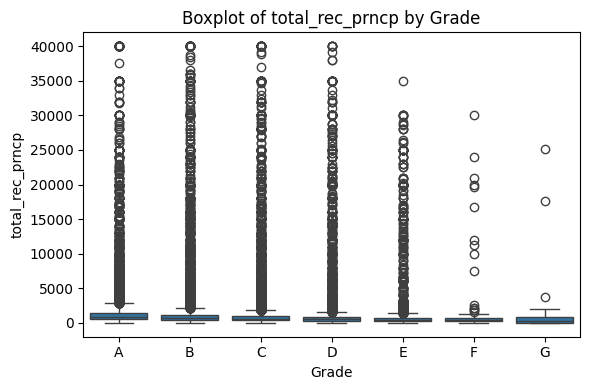

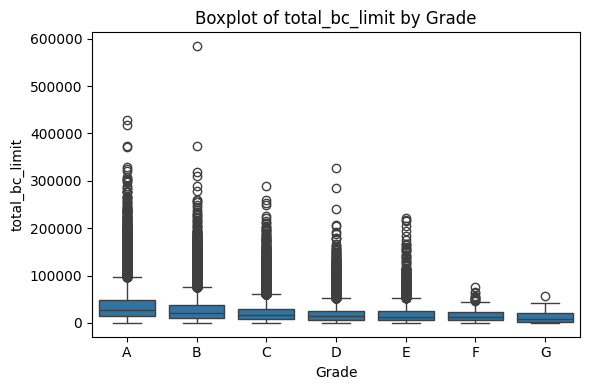

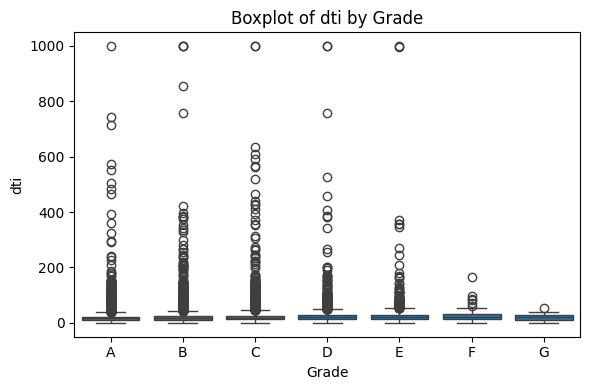

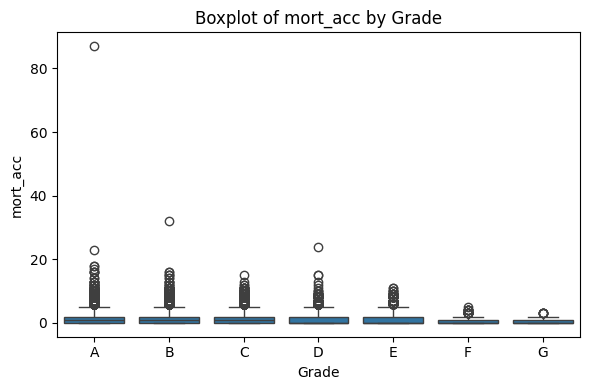

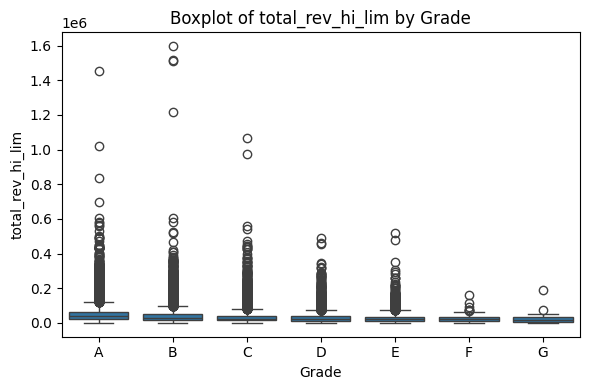

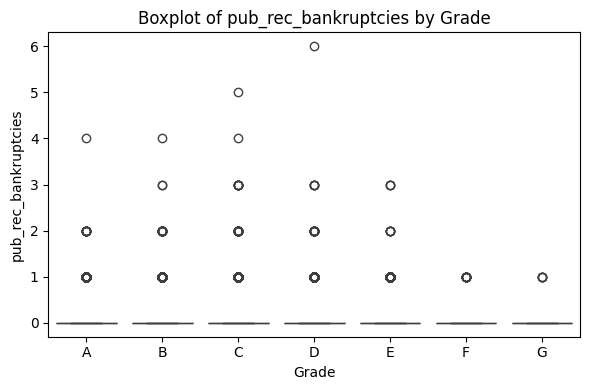

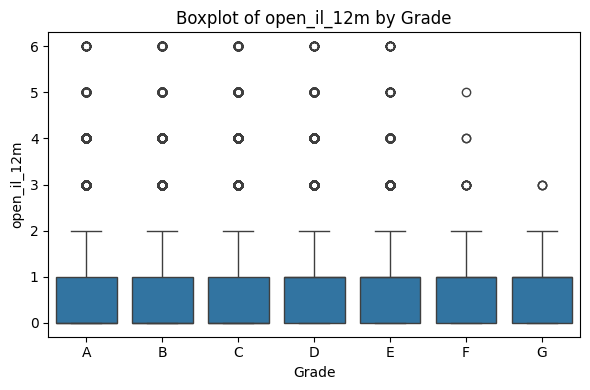

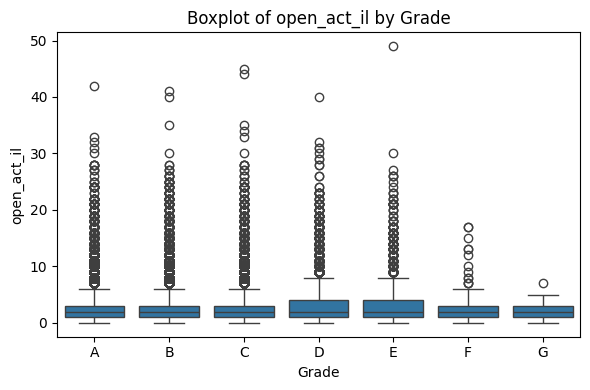

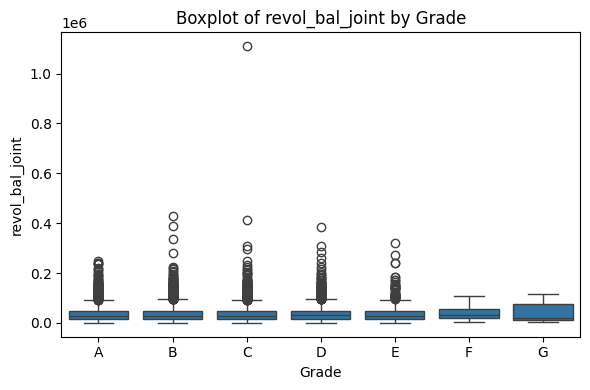

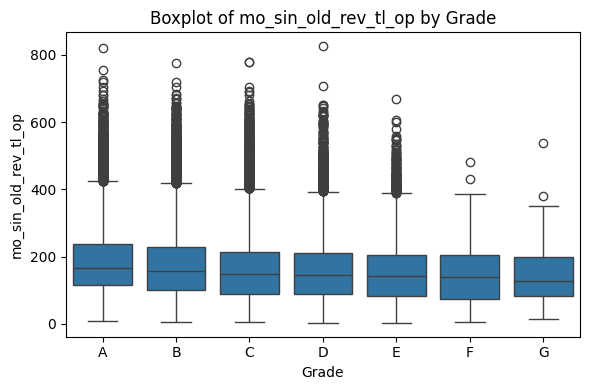

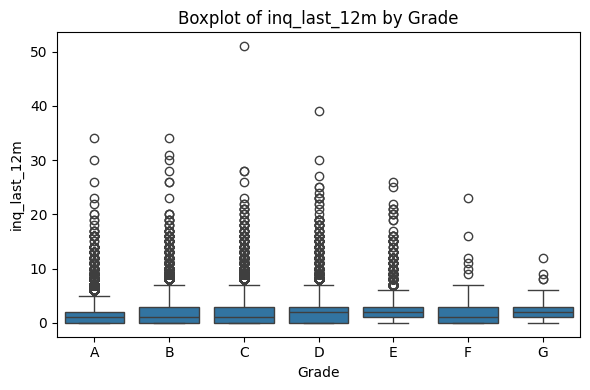

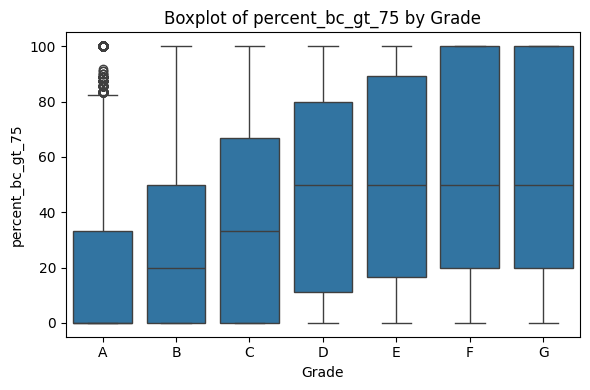

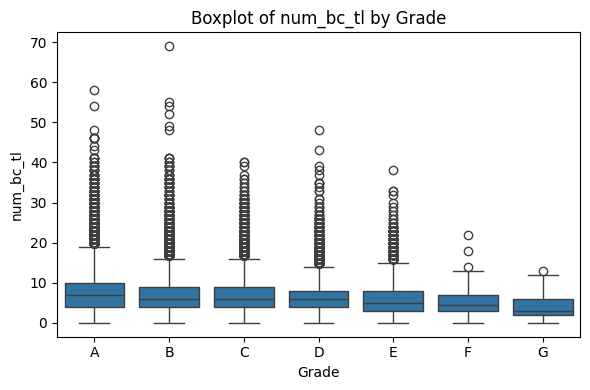

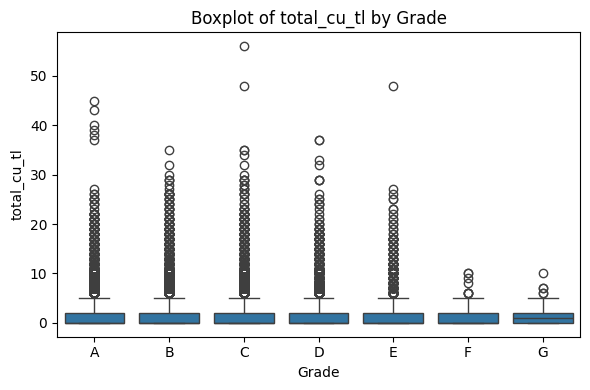

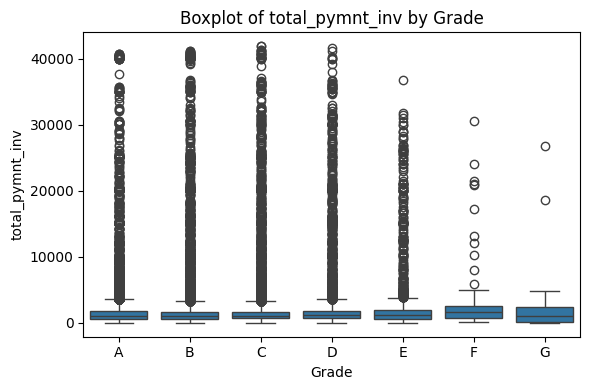

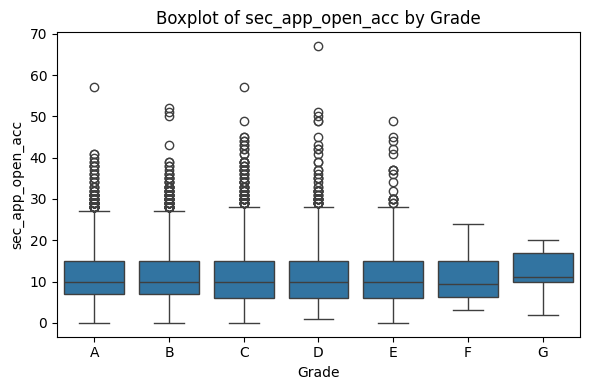

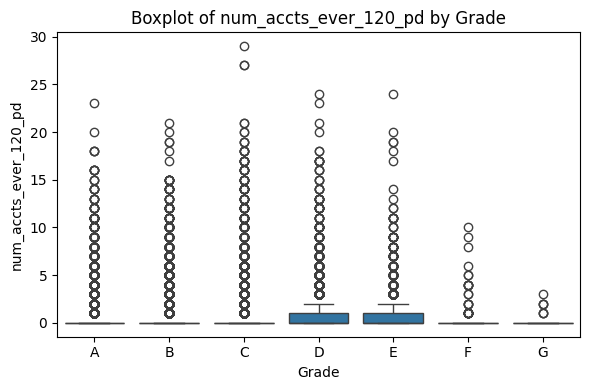

In [21]:
import seaborn as sns

num_features = set(kept) & set(numerical)

for col in num_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x='grade', y=col, order=sorted(df['grade'].unique()))
    plt.title(f'Boxplot of {col} by Grade')
    plt.xlabel('Grade')
    plt.ylabel(col)
    plt.tight_layout()

In [22]:
df['emp_length'].unique()

array(['10+ years', '6 years', '4 years', '< 1 year', '2 years',
       '9 years', nan, '5 years', '3 years', '7 years', '1 year',
       '8 years'], dtype=object)

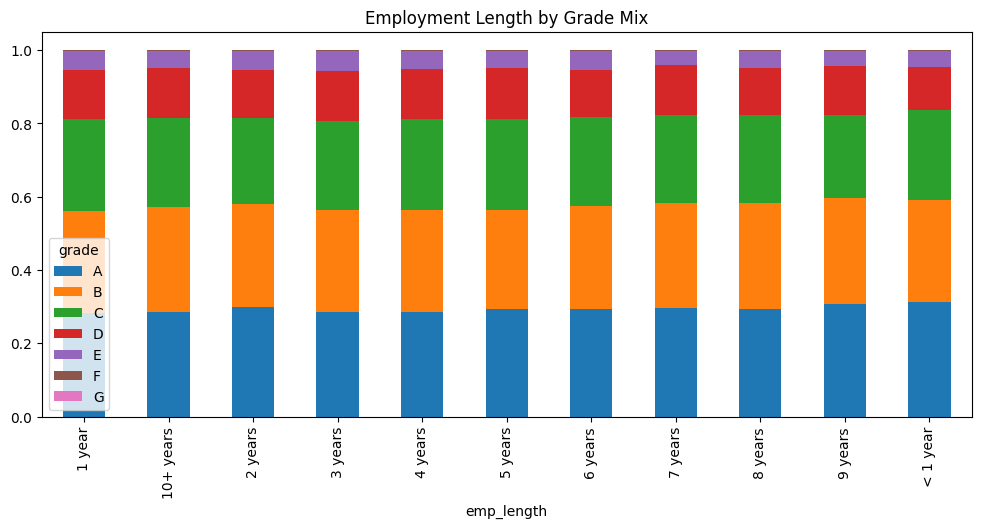

In [23]:
# Employment Length & Home Ownership
# Employment length
emp_grade = df.groupby(['emp_length', 'grade']).size().unstack(fill_value=0)
emp_grade_pct = emp_grade.div(emp_grade.sum(axis=1), axis=0)
emp_grade_pct.plot(kind='bar', stacked=True, figsize=(12, 5))
plt.title('Employment Length by Grade Mix')

order = ['< 1 year', '2 years', '3 years', '4 years', '5 years', '6 years', '7 years', '8 years', '9 years', '10+ years']


Text(0.5, 1.0, 'Home Ownership by Grade')

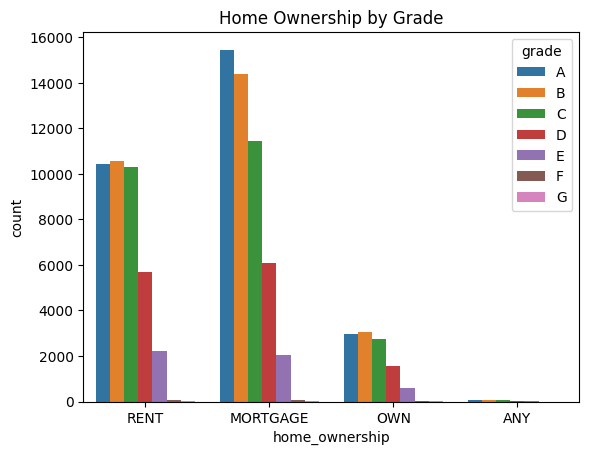

In [24]:
# Home ownership
sns.countplot(data=df, x='home_ownership', hue='grade', 
              hue_order=list('ABCDEFG'))
plt.title('Home Ownership by Grade')

### Correlation between categorical variables and target

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:580: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = self.plt.figure(figsize=self.figsize)


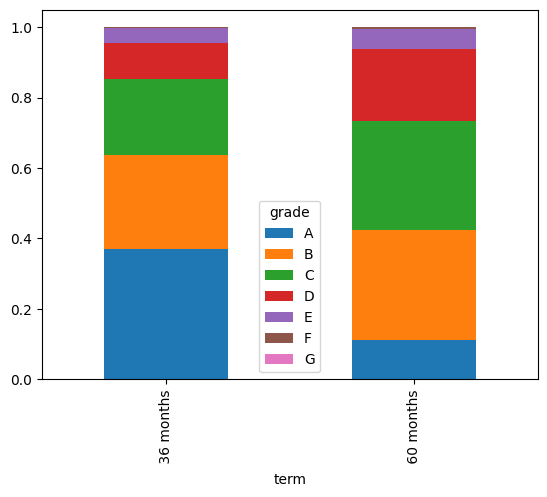

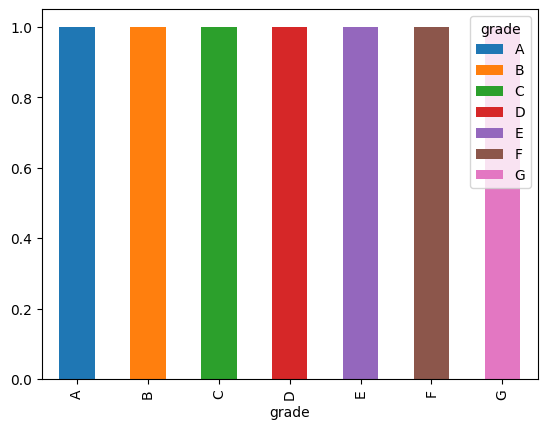

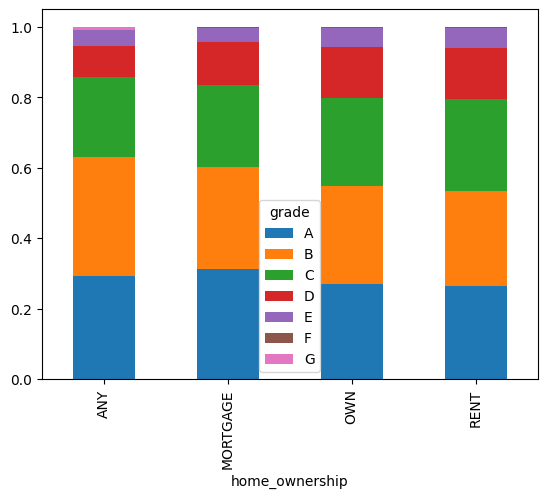

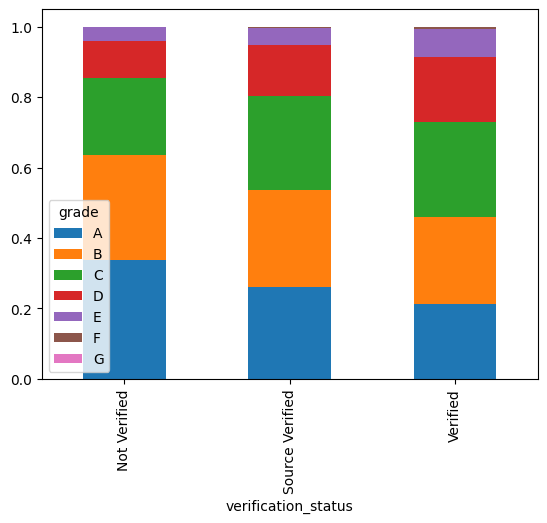

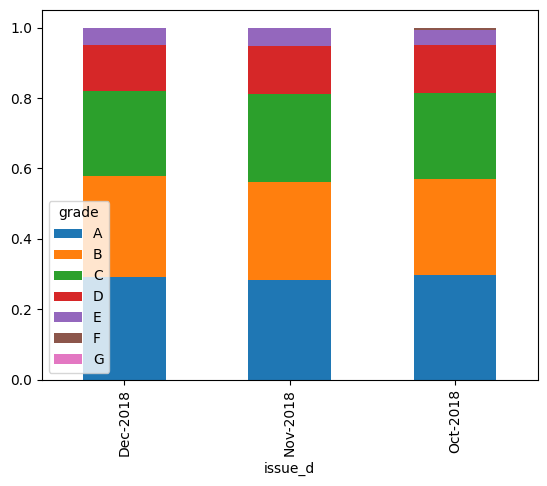

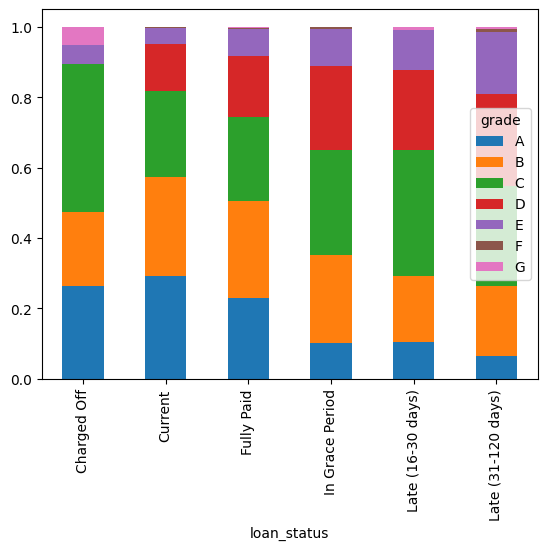

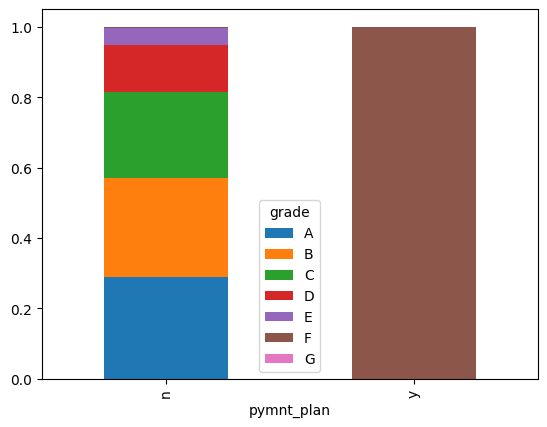

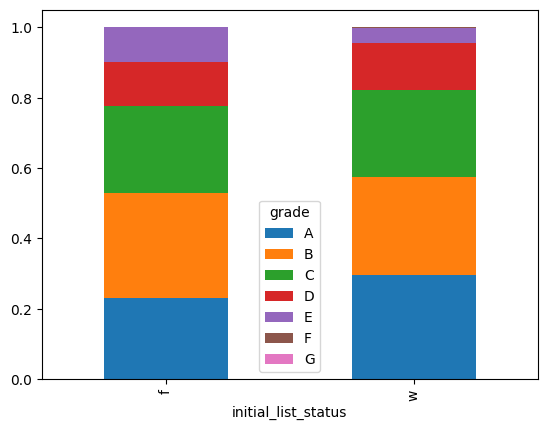

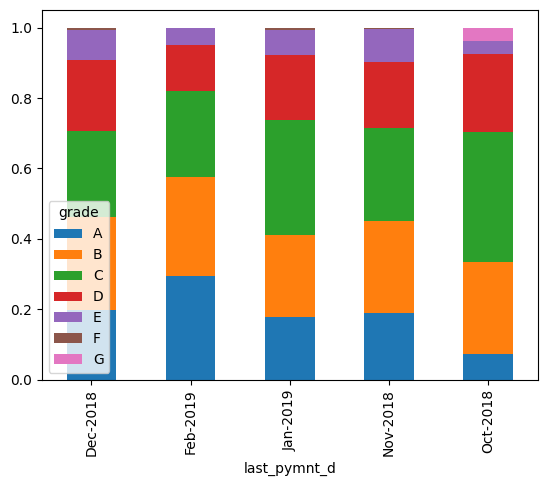

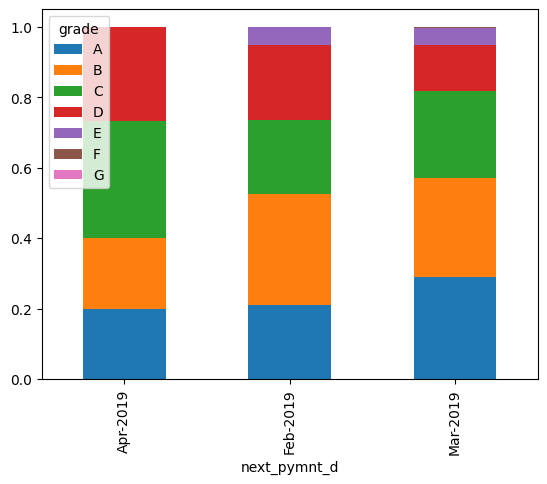

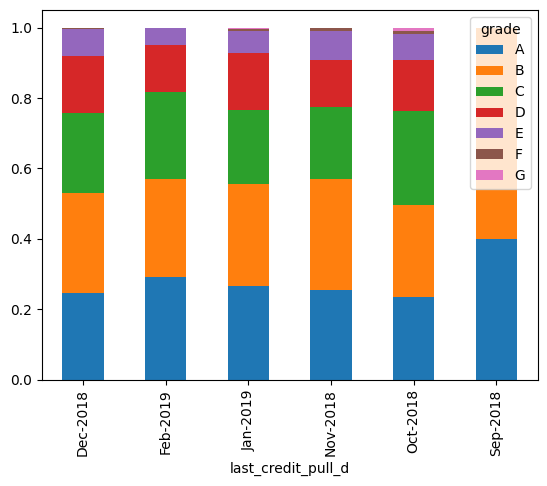

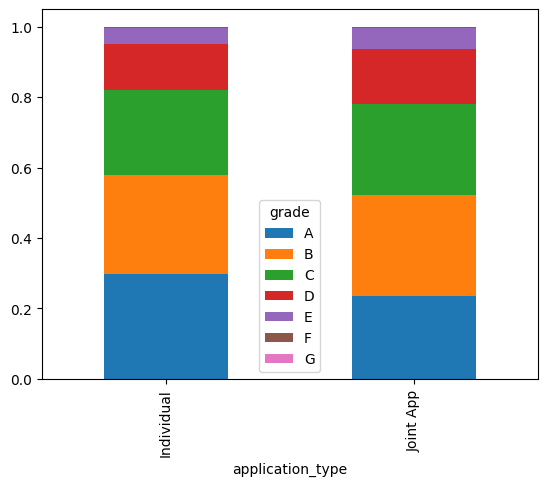

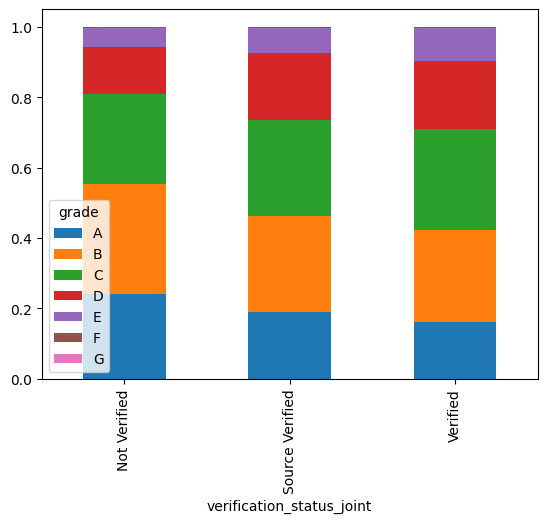

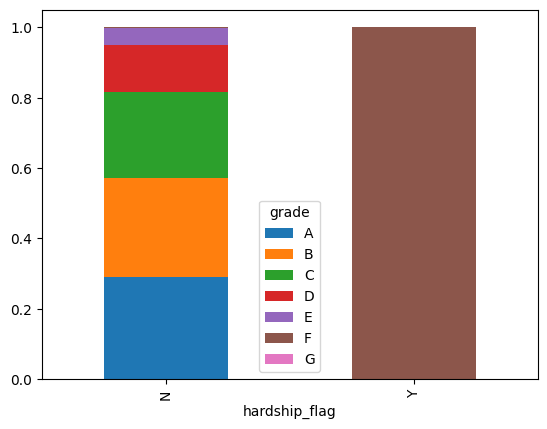

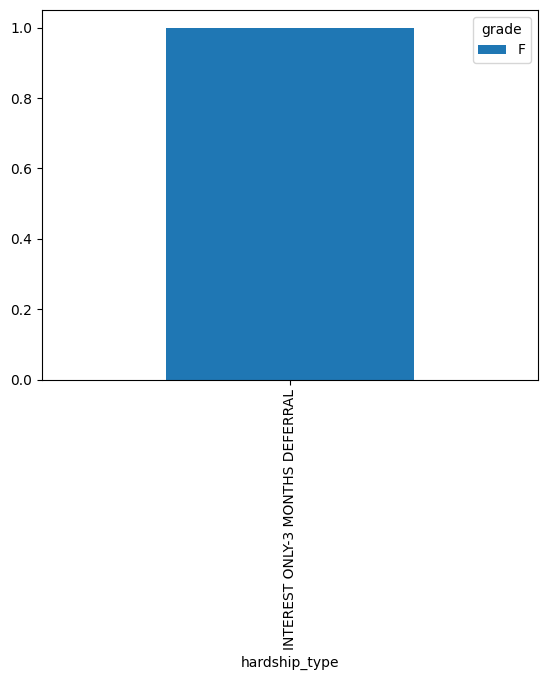

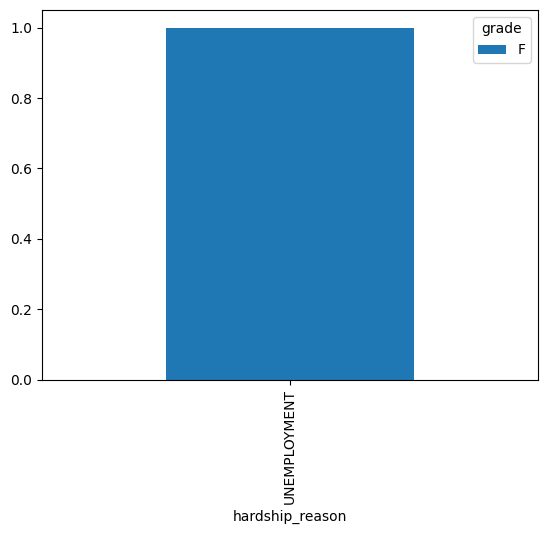

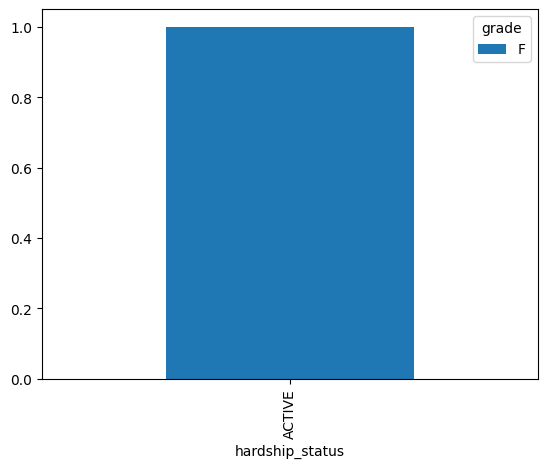

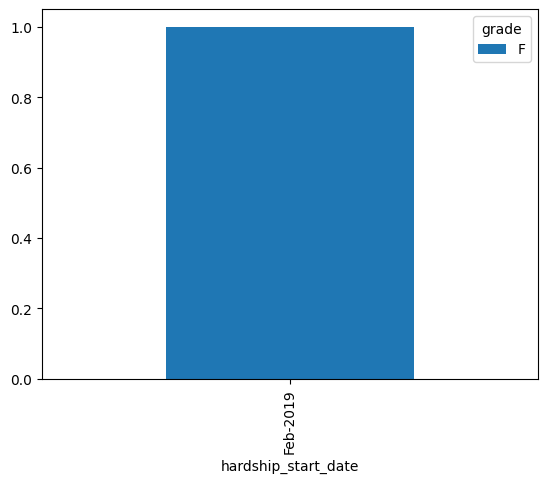

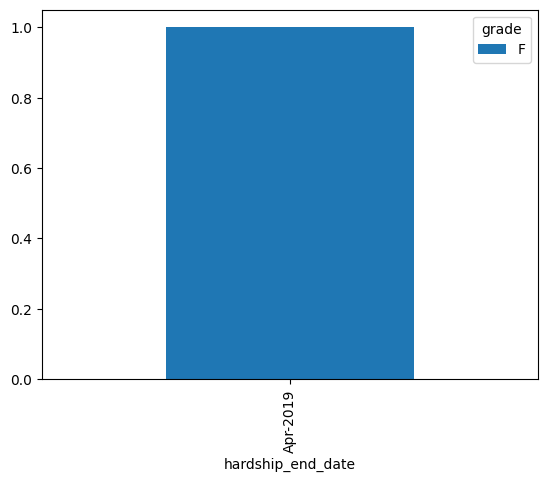

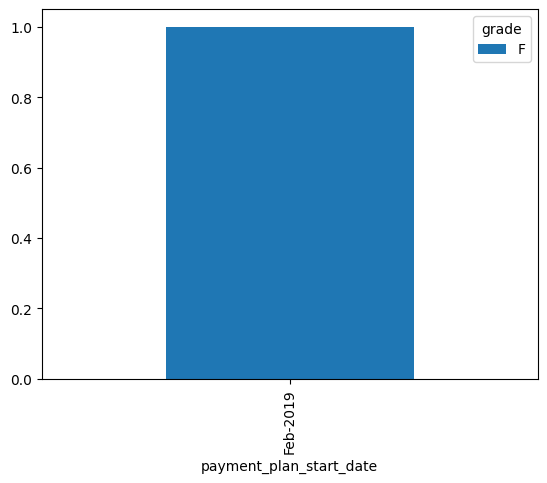

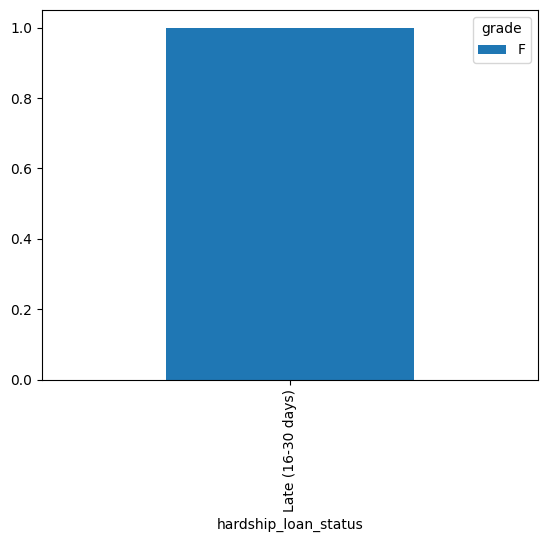

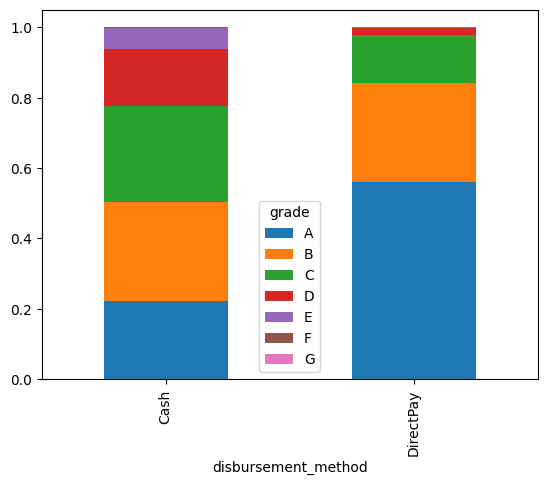

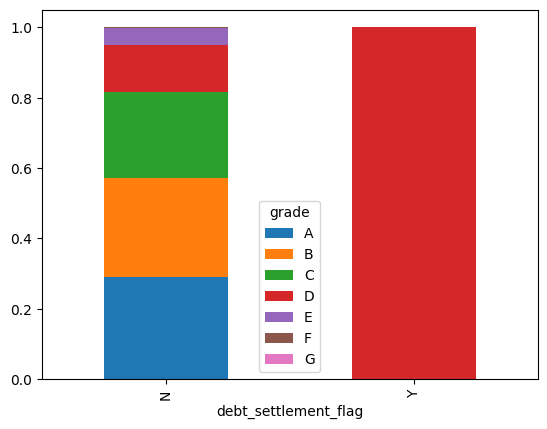

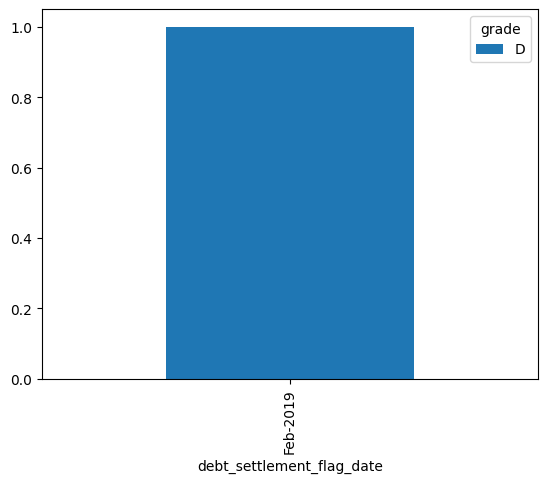

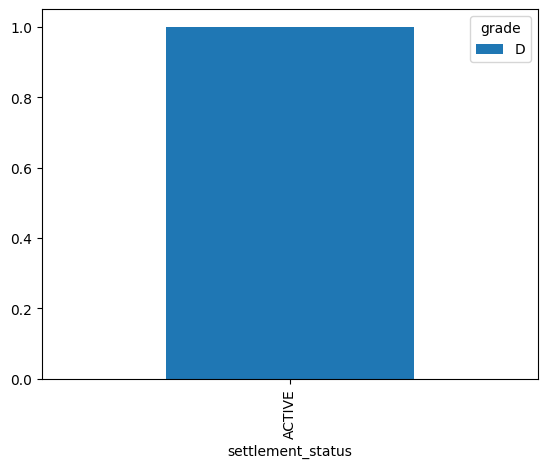

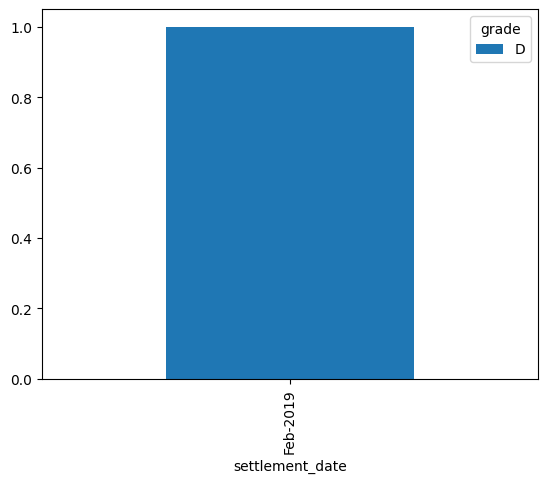

In [25]:

for var in categorical:
    if df[var].nunique() < 10: 
        pd.crosstab(df[var], df['grade'], normalize='index').plot(kind='bar', stacked=True)

### Missing value vs. target variable correlation

In [26]:
for col in df.columns[df.isnull().any()]:
    null_by_grade = df.groupby('grade')[col].apply(lambda x: x.isnull().mean())
    if null_by_grade.std() > 0.01:  # meaningful variation
        print(f"{col}:\n{null_by_grade}\n")

emp_title:
grade
A    0.160533
B    0.163077
C    0.172871
D    0.164304
E    0.169846
F    0.172414
G    0.210526
Name: emp_title, dtype: float64

emp_length:
grade
A    0.082409
B    0.090420
C    0.099441
D    0.100412
E    0.102154
F    0.103448
G    0.140351
Name: emp_length, dtype: float64

mths_since_last_delinq:
grade
A    0.638333
B    0.571179
C    0.509724
D    0.482265
E    0.506462
F    0.632184
G    0.666667
Name: mths_since_last_delinq, dtype: float64

mths_since_last_record:
grade
A    0.900176
B    0.877398
C    0.862641
D    0.861867
E    0.889641
F    0.913793
G    0.929825
Name: mths_since_last_record, dtype: float64

last_pymnt_d:
grade
A    0.000346
B    0.000997
C    0.001549
D    0.001875
E    0.004923
F    0.000000
G    0.035088
Name: last_pymnt_d, dtype: float64

next_pymnt_d:
grade
A    0.019419
B    0.024100
C    0.023851
D    0.031796
E    0.038359
F    0.051724
G    0.105263
Name: next_pymnt_d, dtype: float64

mths_since_last_major_derog:
grade
A    0.8363

### Check correlation

In [27]:
# Encode grade as numeric for correlation
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade_num'] = df['grade'].map(grade_map)

correlations = df.select_dtypes(include='number').corr()['grade_num'].sort_values().dropna()
print(correlations.tail(10))  # most positively correlated
print(correlations.head(10))  # most negatively correlated

inq_last_6mths        0.110363
dti_joint             0.210092
revol_util            0.255699
sec_app_revol_util    0.257609
bc_util               0.274558
percent_bc_gt_75      0.276472
all_util              0.280860
total_rec_int         0.413638
int_rate              0.973189
grade_num             1.000000
Name: grade_num, dtype: float64
bc_open_to_buy         -0.288923
total_bc_limit         -0.238780
total_rev_hi_lim       -0.199010
pct_tl_nvr_dlq         -0.120007
sec_app_mort_acc       -0.114511
tot_hi_cred_lim        -0.109124
num_bc_tl              -0.099549
mo_sin_old_rev_tl_op   -0.098971
mort_acc               -0.097873
annual_inc_joint       -0.096345
Name: grade_num, dtype: float64


In [28]:
del df['grade_num']

<Axes: xlabel='grade'>

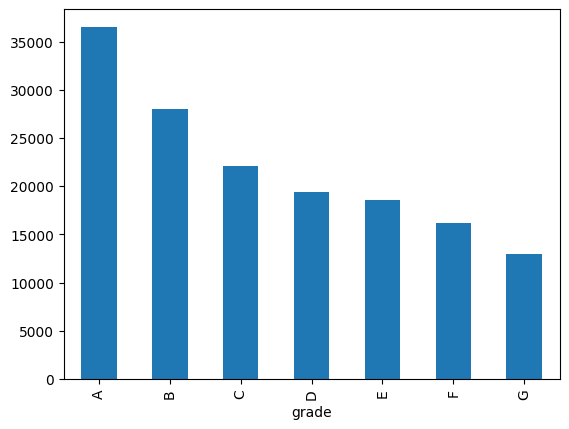

In [29]:
df.groupby('grade')['total_bc_limit'].mean().plot(kind='bar')

Text(0.5, 1.0, 'Feature Correlation Heatmap (|r| > 0.5)')

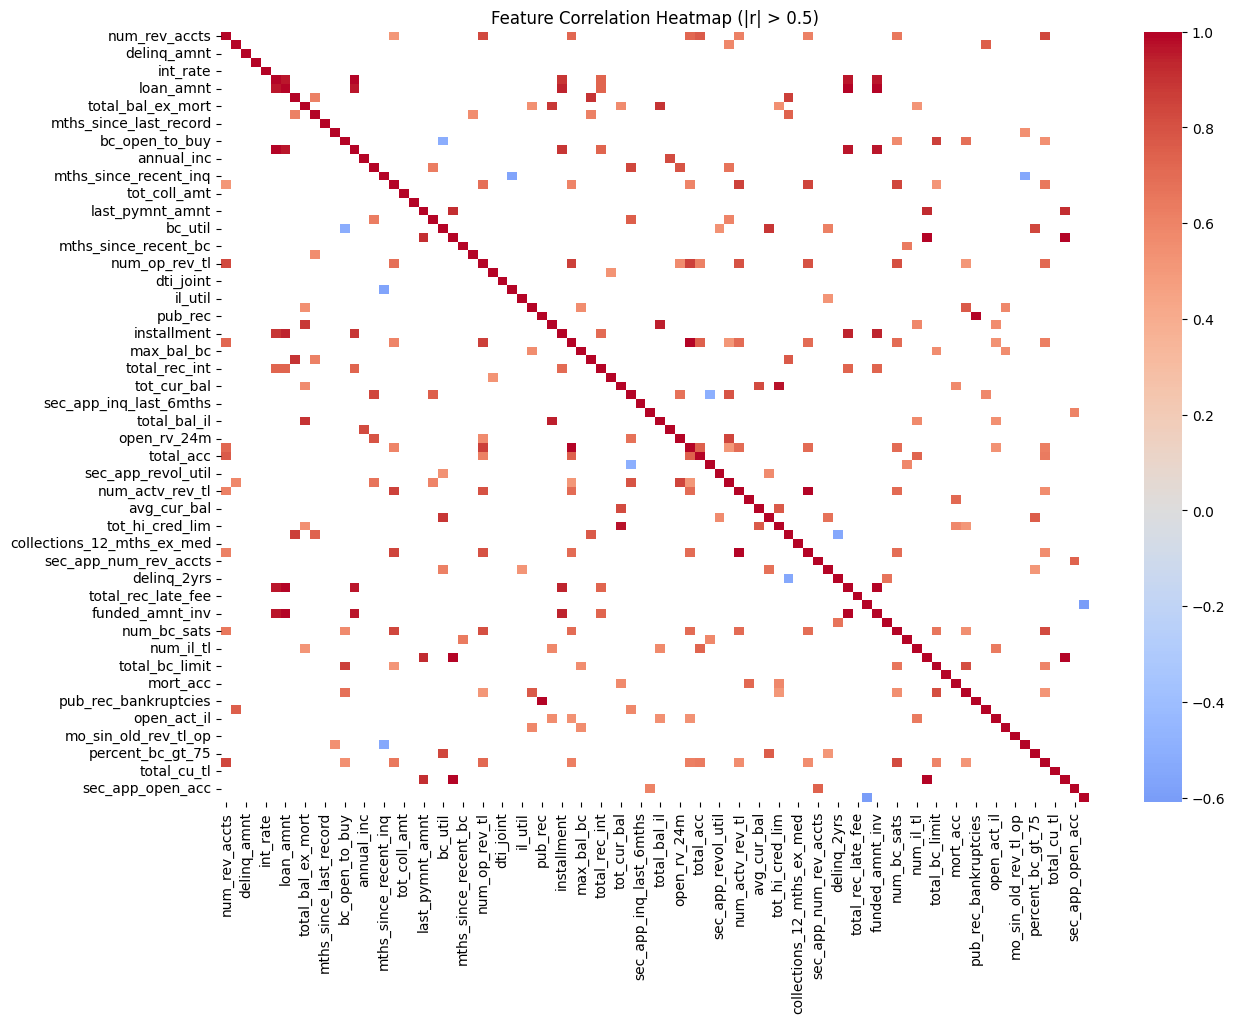

In [30]:
corr = df[list(num_features)].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, 
            mask=corr.abs() < 0.5,  # only show meaningful correlations
            annot=False)
plt.title('Feature Correlation Heatmap (|r| > 0.5)')

### Target variable vs. missing value correlation

In [31]:
for col in df.columns[df.isnull().any()]:
    null_by_grade = df.groupby('grade')[col].apply(lambda x: x.isnull().mean())
    if null_by_grade.std() > 0.01:  # meaningful variation
        print(f"{col}:\n{null_by_grade}\n")

emp_title:
grade
A    0.160533
B    0.163077
C    0.172871
D    0.164304
E    0.169846
F    0.172414
G    0.210526
Name: emp_title, dtype: float64

emp_length:
grade
A    0.082409
B    0.090420
C    0.099441
D    0.100412
E    0.102154
F    0.103448
G    0.140351
Name: emp_length, dtype: float64

mths_since_last_delinq:
grade
A    0.638333
B    0.571179
C    0.509724
D    0.482265
E    0.506462
F    0.632184
G    0.666667
Name: mths_since_last_delinq, dtype: float64

mths_since_last_record:
grade
A    0.900176
B    0.877398
C    0.862641
D    0.861867
E    0.889641
F    0.913793
G    0.929825
Name: mths_since_last_record, dtype: float64

last_pymnt_d:
grade
A    0.000346
B    0.000997
C    0.001549
D    0.001875
E    0.004923
F    0.000000
G    0.035088
Name: last_pymnt_d, dtype: float64

next_pymnt_d:
grade
A    0.019419
B    0.024100
C    0.023851
D    0.031796
E    0.038359
F    0.051724
G    0.105263
Name: next_pymnt_d, dtype: float64

mths_since_last_major_derog:
grade
A    0.8363

### Recheck missing values

In [32]:
df.isnull().mean().sort_values(ascending = False)

,0
id,1.00000
member_id,1.00000
url,1.00000
desc,1.00000
hardship_start_date,0.99999
hardship_loan_status,0.99999
orig_projected_additional_accrued_interest,0.99999
deferral_term,0.99999
hardship_status,0.99999
settlement_status,0.99999


### Data split

In [33]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size = 0.2, stratify=df['grade'])

df_train, df_val = train_test_split(df_full_train, test_size = 0.25, stratify=df_full_train['grade'])

df_train.shape, df_val.shape, df_test.shape

((60000, 145), (20000, 145), (20000, 145))

In [34]:
y_train = df_train['grade']
y_val = df_val['grade']
y_test = df_test['grade']

del df_train['grade']
del df_val['grade']
del df_test['grade']


### Data preprocessing

In [35]:
from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer(sparse = False)

train_dict = df_train.to_dict(orient = 'records')
val_dict = df_val.to_dict(orient = 'records')
test_dict = df_test.to_dict(orient = 'records')

X_train = dv.fit_transform(train_dict)
X_val = dv.transform(val_dict)
X_test = dv.transform(test_dict)



### Model development

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, criterion='log_loss', max_features='sqrt', max_depth=8,
                               random_state=42, n_jobs=-1)


model.fit(X_train, y_train)



RandomForestClassifier(criterion='log_loss', max_depth=8, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [37]:
from sklearn.metrics import log_loss, accuracy_score, f1_score, confusion_matrix, classification_report

y_pred = model.predict_proba(X_val)

y_pred_class = model.predict(X_val)

print('log loss is ', log_loss(y_val, y_pred))



log loss is  1.2253349563374951


### Hyperparameter tuning


In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 9, 13, None],
    'min_samples_leaf': [5, 7, 9, 11]
}

search = GridSearchCV(
    model, 
    param_grid, 
    cv=3, 
    scoring='f1_weighted',
    n_jobs=1,
    verbose=2
)

search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best score:", search.best_score_)

Fitting 3 folds for each of 64 candidates, totalling 192 fits


: 

: 

: 